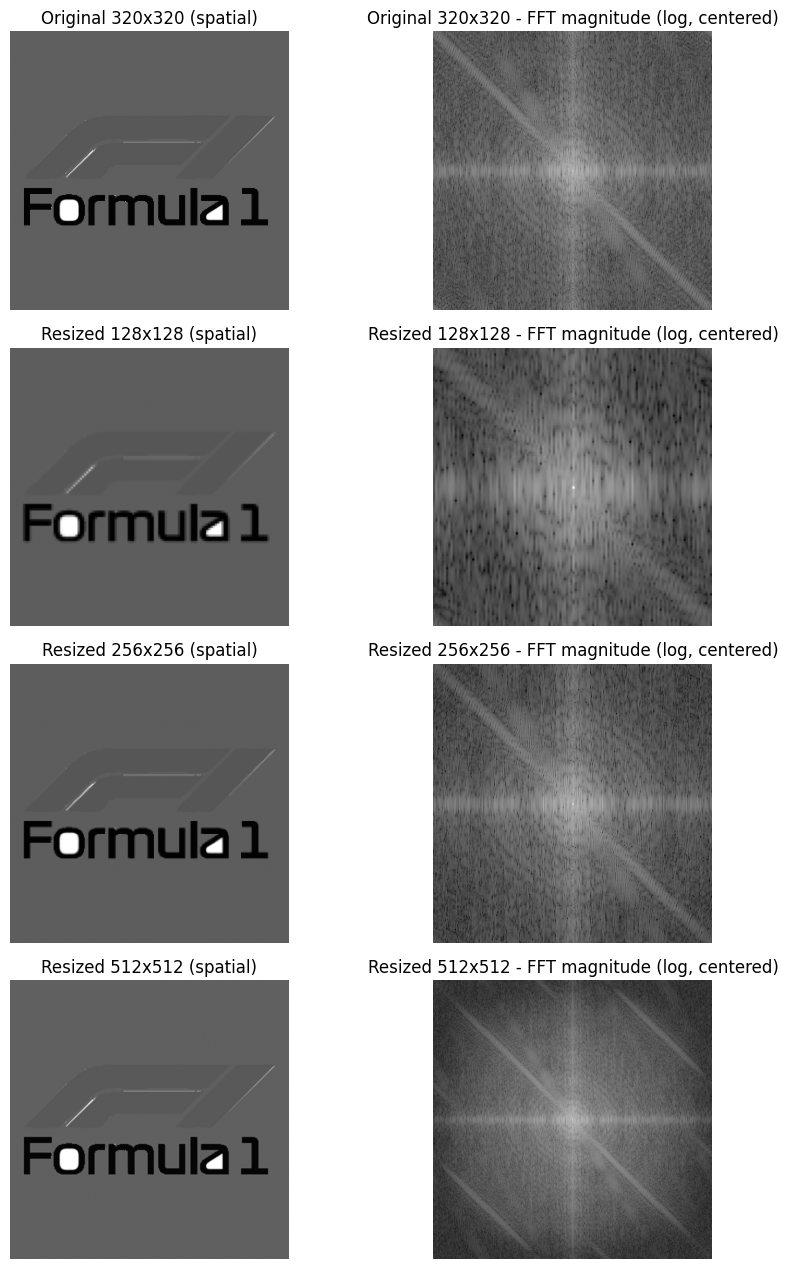

In [1]:
"""
Fourier Transform Magnitude Visualizer
--------------------------------------
What this script does:
1) Load a color image and convert it to grayscale (or generate a synthetic image).
2) Resize it to several different sizes (e.g., 128x128, 256x256, 512x512).
3) Compute the centered Fourier Transform magnitude (with log scaling) for each size.
4) Plot the image and its FT magnitude side by side so you can compare.

Why log scaling?
- Magnitudes can vary by several orders of magnitude. log(1 + |F|) compresses the range
  so both low and high frequencies are visible.

How to use:
- If you have an image, set IMAGE_PATH = "path/to/your_image.jpg".
- If IMAGE_PATH is None or file is missing, the script will generate a synthetic test image.
"""

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

# -----------------------------
# Configuration: change as you like
# -----------------------------
IMAGE_PATH = "images/f1-logo.png"
TARGET_SIZES = [(128, 128), (256, 256), (512, 512)]  # (width, height)


def load_grayscale_image(image_path: str | None, fallback_size: tuple[int, int] = (512, 512)) -> np.ndarray:
    """
    Load an image from disk and convert to grayscale (uint8).
    If image_path is None or file not found, generate a synthetic test image.

    Returns:
        gray_image (H, W), dtype=uint8, range [0, 255]
    """
    if image_path and os.path.exists(image_path):
        # Read BGR image with OpenCV and convert to grayscale
        bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if bgr is None:
            raise ValueError(f"Failed to read image from {image_path}")
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        return gray
    else:
        # Generate a synthetic image with edges, circles, text, and gradients
        w, h = fallback_size
        img = np.zeros((h, w), np.uint8)

        # Horizontal gradient
        for x in range(w):
            img[:, x] = (x / max(w - 1, 1)) * 255

        # Add a checkerboard patch (high frequencies)
        cb_size = 16
        for y in range(0, h, cb_size):
            for x in range(0, w, cb_size):
                if (x // cb_size + y // cb_size) % 2 == 0:
                    img[y:y + cb_size, x:x + cb_size] = 255 - img[y:y + cb_size, x:x + cb_size]

        # Draw shapes (different orientations/frequencies)
        cv2.circle(img, (w // 3, h // 3), 50, 200, 2)
        cv2.rectangle(img, (w // 2, h // 2), (w // 2 + 120, h // 2 + 60), 50, 3)
        cv2.line(img, (20, h - 20), (w - 20, 20), 180, 2)

        # Add text (introduces additional oriented frequencies)
        cv2.putText(img, "FFT", (w // 4, 7 * h // 8), cv2.FONT_HERSHEY_SIMPLEX, 2, 220, 3, cv2.LINE_AA)

        return img


def choose_interpolation(original_shape: tuple[int, int], new_size: tuple[int, int]) -> int:
    """
    Pick a good interpolation method:
    - INTER_AREA is generally best for downscaling.
    - INTER_CUBIC is good for upscaling (smooth, less aliasing than nearest).
    """
    orig_h, orig_w = original_shape
    new_w, new_h = new_size
    if new_w < orig_w or new_h < orig_h:
        return cv2.INTER_AREA
    return cv2.INTER_CUBIC


def resize_image(image: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    """
    Resize image to (width, height) with a sensible interpolation choice.
    """
    interp = choose_interpolation(image.shape, (size[1], size[0]))  # image.shape is (H, W)
    return cv2.resize(image, size, interpolation=interp)


def fft_magnitude_centered(gray_image: np.ndarray) -> np.ndarray:
    """
    Compute centered FFT magnitude with log scaling.

    Steps:
    - Convert to float (prevents overflow and improves FT accuracy).
    - 2D FFT to go from spatial domain to frequency domain.
    - fftshift to move DC (low frequency) to the center of the spectrum.
    - Take magnitude and apply log(1 + magnitude) for better visibility.
    - Normalize to [0, 255] for display.

    Returns:
        mag_uint8: (H, W) uint8 image of the log-magnitude spectrum.
    """
    # Convert to float32
    img_float = gray_image.astype(np.float32)

    # 2D FFT
    spectrum = np.fft.fft2(img_float)

    # Shift the zero frequency (DC component) to the center
    spectrum_centered = np.fft.fftshift(spectrum)

    # Magnitude and log scaling
    magnitude = np.abs(spectrum_centered)
    log_magnitude = np.log1p(magnitude)  # log(1 + |F|)

    # Normalize to 0..255 for visualization
    log_min, log_max = log_magnitude.min(), log_magnitude.max()
    mag_norm = (log_magnitude - log_min) / (log_max - log_min + 1e-12)
    mag_uint8 = (mag_norm * 255).astype(np.uint8)
    return mag_uint8


def show_images_and_fft(images: list[tuple[str, np.ndarray]]) -> None:
    """
    Display each image alongside its Fourier magnitude image.
    images: list of (title, grayscale_image)
    """
    num = len(images)
    plt.figure(figsize=(10, 3.2 * num))
    for idx, (title, gray_img) in enumerate(images, start=1):
        mag = fft_magnitude_centered(gray_img)

        # Left: spatial image
        ax1 = plt.subplot(num, 2, 2 * idx - 1)
        ax1.imshow(gray_img, cmap="gray")
        ax1.set_title(f"{title} (spatial)")
        ax1.set_axis_off()

        # Right: frequency magnitude (log)
        ax2 = plt.subplot(num, 2, 2 * idx)
        ax2.imshow(mag, cmap="gray")
        ax2.set_title(f"{title} - FFT magnitude (log, centered)")
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()


def main():
    # 1) Load (or synthesize) a grayscale image
    base_gray = load_grayscale_image(IMAGE_PATH)

    # 2) Prepare resized versions at different sizes
    items_to_show = []

    # Original (whatever size it is)
    h, w = base_gray.shape
    items_to_show.append((f"Original {w}x{h}", base_gray))

    # Requested target sizes
    for size in TARGET_SIZES:
        # size is (width, height)
        resized = resize_image(base_gray, size)
        items_to_show.append((f"Resized {size[0]}x{size[1]}", resized))

    # 3) Visualize images and their Fourier magnitude spectra
    show_images_and_fft(items_to_show)

    # -----------------------------
    # (Optional) Zero-padding demo:
    # Zero-padding increases frequency *sampling resolution* without adding detail.
    # The content stays the same, but the spectrum grid becomes denser.
    # Uncomment below to see the effect of padding to a larger canvas.
    # -----------------------------
    # pad_to = (1024, 1024)  # (H, W)
    # padded = np.zeros(pad_to, dtype=base_gray.dtype)
    # ph, pw = padded.shape
    # y0 = (ph - h) // 2
    # x0 = (pw - w) // 2
    # padded[y0:y0 + h, x0:x0 + w] = base_gray
    # show_images_and_fft([("Zero-padded 1024x1024 (centered)", padded)])


if __name__ == "__main__":
    main()


In [10]:
import numpy as np
import cv2

# -----------------------------
# Utilities
# -----------------------------
def to_float_gray(img_bgr):
    if img_bgr.ndim == 3:
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img_bgr
    return img_gray.astype(np.float32)

def fft_mag_phase(img):
    F = np.fft.fft2(img)
    F = np.fft.fftshift(F)                      # center DC
    mag = np.abs(F).astype(np.float32)
    phase = np.angle(F).astype(np.float32)
    return mag, phase

def ifft_from_mag_phase(mag, phase):
    F = (mag * np.exp(1j * phase)).astype(np.complex64)
    F = np.fft.ifftshift(F)
    img = np.fft.ifft2(F).real
    return img

def warp_to_log_polar(mag, num_rho=256, num_theta=180):
    """
    Forward warp: Cartesian -> log-polar (OpenCV uses (cols=num_theta, rows=num_rho))
    Returns LP of shape (num_rho, num_theta)
    """
    h, w = mag.shape
    center = (w/2.0, h/2.0)
    max_radius = min(center) - 1e-3
    flags = cv2.WARP_POLAR_LOG + cv2.WARP_FILL_OUTLIERS
    lp = cv2.warpPolar(mag, (num_theta, num_rho), center, max_radius, flags)
    return lp, center, max_radius

def warp_from_log_polar(lp, center, max_radius, out_shape):
    """
    Inverse warp: log-polar -> Cartesian magnitude
    """
    num_rho, num_theta = lp.shape
    flags = cv2.WARP_POLAR_LOG + cv2.WARP_INVERSE_MAP + cv2.WARP_FILL_OUTLIERS
    
    # Ensure lp values are reasonable
    lp = np.maximum(lp, 1e-8)
    
    mag_cart = cv2.warpPolar(lp, (out_shape[1], out_shape[0]), center, max_radius, flags)
    
    # Check for invalid values
    mag_cart = np.nan_to_num(mag_cart, nan=1e-8, posinf=1e8, neginf=1e-8)
    
    return mag_cart

def g1_signature_from_lp(lp_log):
    """
    lp_log: log of magnitude in log-polar coordinates, shape (K=num_rho, N=num_theta)
    Returns:
      g  : per-angle log-sum  (length N)
      g1 : g(theta) + g(theta+90°)  (length N/2)
    """
    K, N = lp_log.shape
    g = lp_log.sum(axis=0)                  # sum along radius -> length N
    half = N // 2
    g1 = g[:half] + g[half:half+half]       # Eq. (12)
    return g, g1

def mix_signature(v, w, alpha=0.30):
    """
    Create target signature s from host v and watermark w.
    We z-score w and scale to v's std so energy is comparable.
    """
    w = np.asarray(w, dtype=np.float32)
    v = np.asarray(v, dtype=np.float32)
    w = (w - w.mean()) / (w.std() + 1e-8)
    w = w * (v.std() + 1e-8)
    s = (1 - alpha) * v + alpha * w
    return s

# -----------------------------
# Core: EMBEDDING
# -----------------------------
def embed_watermark(img_bgr, w, alpha=0.30, num_rho=256, num_theta=180, iters=6):
    """
    Inputs
      img_bgr : uint8 image (H×W or H×W×3). We embed in luminance if color.
      w       : watermark vector of length N/2 (N is num_theta, e.g. 180 -> len=90)
      alpha   : mix strength (0..1) for the target signature
      iters   : number of back-projection refinements in log-polar domain
    Output
      watermarked image (same size, uint8)
    """
    # 1) Prepare grayscale (use Y channel if you prefer)
    img = to_float_gray(img_bgr)

    # 2) FFT -> magnitude & phase
    mag, phase = fft_mag_phase(img)
    mag = np.maximum(mag, 1e-8)

    # 3) Cartesian mag -> log-polar mag
    lp, center, max_radius = warp_to_log_polar(mag, num_rho=num_rho, num_theta=num_theta)
    lp = np.maximum(lp, 1e-8)                     # avoid log(0)
    lp_log = np.log(lp)

    # 4) Build host signature v = g1(theta)  (length N/2)
    g, v = g1_signature_from_lp(lp_log)
    N = num_theta
    half = N // 2
    assert len(w) == half, f"Watermark length must be {half}"

    # 5) Target signature s
    s = mix_signature(v, w, alpha=alpha)

    # 6) Iterative back-projection in log-polar space
    K = num_rho
    g_curr = g.copy()
    lp_log_mod = lp_log.copy()

    for _ in range(iters):
        # recompute per-angle sums from lp_log_mod
        g_curr = lp_log_mod.sum(axis=0)           # length N
        v_curr = g_curr[:half] + g_curr[half:half+half]     # current g1

        # error between desired and current g1
        err = (s - v_curr)                        # length half

        # split each g1 target back to two columns while preserving their difference:
        # let a=g(theta), b=g(theta+90), we know:
        #   a + b should equal s_target (v_target)
        #   (a - b) keep as current difference d = g_curr[j] - g_curr[j+half]
        d = g_curr[:half] - g_curr[half:half+half]
        a_target = (s + d) / 2.0
        b_target = (s - d) / 2.0

        # convert target a,b to per-sample offsets (constant add per column)
        delta_a = (a_target - g_curr[:half]) / K
        delta_b = (b_target - g_curr[half:half+half]) / K

        # apply column-wise offsets
        lp_log_mod[:, :half]            += delta_a[np.newaxis, :]
        lp_log_mod[:, half:half+half]   += delta_b[np.newaxis, :]

    # 7) Back to Cartesian magnitude
    lp_mod = np.exp(lp_log_mod)
    mag_mod = warp_from_log_polar(lp_mod, center, max_radius, out_shape=img.shape)

    # 8) Re-attach original phase & iFFT
    mag_mod = np.maximum(mag_mod, 1e-8)
    wm_float = ifft_from_mag_phase(mag_mod, phase)

    # 9) Output uint8 (preserve dynamic range)
    wm_float = np.clip(wm_float, 0, 255)
    watermarked = wm_float.astype(np.uint8)
    return watermarked

# Test with minimal changes
def simple_embed_test(img_bgr, alpha=0.1):
    img = to_float_gray(img_bgr)
    print(f"Gray image range: [{img.min():.3f}, {img.max():.3f}]")
    
    # Just add small random noise to test the pipeline
    noise = np.random.normal(0, alpha * img.std(), img.shape)
    result = img + noise
    result = np.clip(result, 0, 255).astype(np.uint8)
    return result

# -----------------------------
# Example usage
# -----------------------------
if __name__ == "__main__":
    # Load host and make a simple watermark vector (length 90 if num_theta=180)
    host = cv2.imread("images/cat.webp")
    NUM_THETA = 180
    W_LEN = NUM_THETA // 2                      # 90
    
    # Example: pseudo-random ±1 pattern as watermark vector
    rng = np.random.RandomState(123)
    w = rng.choice([0, 1], size=W_LEN).astype(np.int32)
    print(w)

    watermarked = embed_watermark(host, w, alpha=0.30, num_rho=256, num_theta=NUM_THETA, iters=6)
    cv2.imshow("f1-logo_watermarked.png", watermarked)
    cv2.waitKey(0)

[0 1 0 0 0 0 0 1 1 0 1 1 0 1 0 1 0 1 1 0 0 0 1 1 1 0 1 0 0 0 0 1 1 1 0 0 1
 0 0 1 0 1 0 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 1 1
 1 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0]


In [27]:
import numpy as np
from numpy import fft as fftnp
from scipy.ndimage import zoom
from scipy.interpolate import griddata
from scipy.interpolate import RectBivariateSpline
from matplotlib.image import imread, imsave
import cv2

# Try these adjusted parameters:
N_THETA = 256
N_R = 128
MIN_DIST = 15   # Increase minimum distance
MAX_DIST = 40   # Decrease maximum distance
ALPHA = 0.1     # Increase embedding strength
R_MIN = 1.0
WM_SIZE = 32

def prepare_watermark(wm_path):
    wm_img = cv2.imread(wm_path)
    if wm_img is None:
        raise ValueError(f"Could not read watermark image: {wm_path}")
    
    if len(wm_img.shape) == 3:
        # Convert to grayscale
        wm_img = cv2.cvtColor(wm_img, cv2.COLOR_BGR2GRAY)
    
    # Use automatic thresholding (Otsu's method) for better results
    _, wm_bin = cv2.threshold(wm_img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    wm_bin = wm_bin.astype(float)
    
    # Resize to target size
    wm_resized = zoom(wm_bin, (WM_SIZE / wm_bin.shape[0], WM_SIZE / wm_bin.shape[1]), order=0)
    
    print(f"Original watermark shape: {wm_img.shape}")
    print(f"Binary watermark range: [{wm_bin.min():.1f}, {wm_bin.max():.1f}]")
    print(f"Resized watermark shape: {wm_resized.shape}")
    
    return wm_resized

def get_groups(n_theta, n_r):
    center_theta, center_r = n_theta // 2, n_r // 2
    dists = []
    for i in range(n_theta):
        for j in range(n_r):
            dist = np.sqrt((i - center_theta) ** 2 + (j - center_r) ** 2)
            if MIN_DIST < dist < MAX_DIST:
                dists.append(((i, j), dist))
    dists.sort(key=lambda x: x[1])
    selected = [p for p, d in dists]
    num_coeffs = len(selected)
    repeats = max(1, num_coeffs // (WM_SIZE * WM_SIZE))
    selected = selected[:(WM_SIZE * WM_SIZE) * repeats]
    groups = [selected[i * repeats:(i + 1) * repeats] for i in range(WM_SIZE * WM_SIZE)]
    return groups

def embed(host_path, wm_path, output_path):
    host_img = cv2.imread(host_path)
    
    if host_img is None:
        raise ValueError(f"Could not read host image: {host_path}")
    
    # Normalize input to [0,1] range
    host_img = host_img.astype(np.float64) / 255.0

    wm = prepare_watermark(wm_path)
    wm_flat = wm.flatten()

    if len(host_img.shape) == 2:
        is_color = False
        Y = host_img
        U, V = None, None
    else:
        is_color = True
        R, G, B = host_img[:, :, 0], host_img[:, :, 1], host_img[:, :, 2]
        Y = 0.299 * R + 0.587 * G + 0.114 * B
        U = -0.147 * R - 0.289 * G + 0.436 * B
        V = 0.615 * R - 0.515 * G - 0.100 * B

    h, w = Y.shape
    size = max(h, w)
    pad_h1 = (size - h) // 2
    pad_h2 = size - h - pad_h1
    pad_w1 = (size - w) // 2
    pad_w2 = size - w - pad_w1
    Y_pad = np.pad(Y, ((pad_h1, pad_h2), (pad_w1, pad_w2)), mode='constant')

    F = fftnp.fft2(Y_pad)
    mag = np.abs(F)
    phase = np.angle(F)

    # Log-polar mapping
    log_r = np.linspace(np.log(R_MIN), np.log(size / 2), N_R)
    theta = np.linspace(0, 2 * np.pi, N_THETA, endpoint=False)
    R_grid, Theta_grid = np.meshgrid(np.exp(log_r), theta)
    X_coords = R_grid * np.cos(Theta_grid) + size / 2
    Y_coords = R_grid * np.sin(Theta_grid) + size / 2  # Use different name
    interpolator = RectBivariateSpline(np.arange(size), np.arange(size), mag, kx=1, ky=1)
    lpm_mag = interpolator.ev(Y_coords, X_coords)  # Use correct coordinates

    # Fourier-Mellin transform
    fmt = fftnp.fft2(lpm_mag)
    fmt_mag = np.abs(fmt)
    fmt_phase = np.angle(fmt)

    # Normalize
    norm = np.linalg.norm(fmt_mag, 'fro')
    fmt_mag_norm = fmt_mag / norm

    # Shift for frequency selection
    fmt_mag_shift = fftnp.fftshift(fmt_mag_norm)

    # Get groups
    groups = get_groups(N_THETA, N_R)
    print(f"Number of groups: {len(groups)}")
    print(f"Expected groups: {WM_SIZE * WM_SIZE}")
    print(f"Group size (repeats): {len(groups[0]) if groups else 0}")

    # Debug: Check delta value
    selected_values = [fmt_mag_shift[p] for group in groups for p in group]
    median_val = np.median(selected_values)
    delta = ALPHA * median_val
    print(f"Median value: {median_val:.6f}")
    print(f"Delta: {delta:.6f}")

    # Compute delta adaptively
    selected_values = [fmt_mag_shift[p] for group in groups for p in group]
    median_val = np.median(selected_values)
    delta = ALPHA * median_val

    # Embed using QIM
    fmt_mag_shift_new = fmt_mag_shift.copy()
    for bit_idx, group in enumerate(groups):
        b = wm_flat[bit_idx]
        for p in group:
            c = fmt_mag_shift_new[p]
            if b == 0:
                c_new = round(c / delta) * delta
            else:
                c_new = round((c - delta / 2) / delta) * delta + delta / 2
            fmt_mag_shift_new[p] = c_new

    # Back to unshifted, denormalize
    fmt_mag_norm_new = fftnp.ifftshift(fmt_mag_shift_new)
    fmt_mag_new = fmt_mag_norm_new * norm
    fmt_new = fmt_mag_new * np.exp(1j * fmt_phase)
    # lpm_mag_new = np.abs(fftnp.ifft2(fmt_new))
    lpm_mag_new = np.real(fftnp.ifft2(fmt_new))
    lpm_mag_new = np.maximum(lpm_mag_new, 0.0)

    # Inverse log-polar
    freq_range = np.arange(size) - size / 2
    fx, fy = np.meshgrid(freq_range, freq_range)
    r = np.sqrt(fx**2 + fy**2)
    theta_vals = np.arctan2(fy, fx) % (2 * np.pi)
    rho = np.log(np.maximum(r, 1e-10))
    mask = (r >= R_MIN) & (r <= size / 2)
    query_points = np.column_stack((rho[mask], theta_vals[mask]))
    Log_r_grid, Theta_grid = np.meshgrid(log_r, theta)
    points = np.column_stack((Log_r_grid.flatten(), Theta_grid.flatten()))
    values = lpm_mag_new.flatten()
    # interp_values = griddata(points, values, query_points, method='linear', fill_value=0)
    # new_mag = mag.copy()
    # new_mag[mask] = interp_values
    # new_mag = (new_mag + new_mag[::-1, ::-1]) / 2  # Symmetrize

    # Build a spline on the (theta, log_r) grid of lpm_mag_new, like you did forward.
    lp_spline = RectBivariateSpline(theta, log_r, lpm_mag_new, kx=1, ky=1)
    # sample back on Cartesian frequency grid (mask region only)
    new_mag = mag.copy()
    rho = np.log(np.maximum(r, R_MIN))
    new_mag[mask] = lp_spline.ev(theta_vals[mask], rho[mask])


    # Inverse DFT
    F_new = new_mag * np.exp(1j * phase)
    Y_pad_new = np.real(fftnp.ifft2(F_new))
    Y_new = Y_pad_new[pad_h1:pad_h1 + h, pad_w1:pad_w1 + w]

    if not is_color:
        watermarked = Y_new
        # Fix: Y_new is in [0,1] range, scale to [0,255]
        watermarked = np.clip(watermarked, 0, 1)
        watermarked = (watermarked * 255).astype(np.uint8)
    else:
        R_new = Y_new + 1.140 * V
        G_new = Y_new - 0.395 * U - 0.581 * V
        B_new = Y_new + 2.032 * U
        watermarked = np.stack((R_new, G_new, B_new), axis=2)
        watermarked = np.clip(watermarked, 0, 1)
        watermarked = (watermarked * 255).astype(np.uint8)

    # Add this before cv2.imwrite in both functions:
    print(f"Image shape: {watermarked.shape}")
    print(f"Image dtype: {watermarked.dtype}")
    print(f"Image range: [{watermarked.min():.3f}, {watermarked.max():.3f}]")

    cv2.imwrite(output_path, watermarked)
    return watermarked

def extract(watermarked_path, output_wm_path):
    watermarked_img = cv2.imread(watermarked_path)

    # Fix: Normalize to [0,1] like in embed function
    watermarked_img = watermarked_img.astype(np.float64) / 255.0

    if len(watermarked_img.shape) == 2:
        Y_lum = watermarked_img
    else:
        R, G, B = watermarked_img[:, :, 0], watermarked_img[:, :, 1], watermarked_img[:, :, 2]
        Y_lum = 0.299 * R + 0.587 * G + 0.114 * B

    h, w = Y_lum.shape
    size = max(h, w)
    pad_h1 = (size - h) // 2
    pad_h2 = size - h - pad_h1
    pad_w1 = (size - w) // 2
    pad_w2 = size - w - pad_w1
    Y_pad = np.pad(Y_lum, ((pad_h1, pad_h2), (pad_w1, pad_w2)), mode='constant')

    F = fftnp.fft2(Y_pad)
    mag = np.abs(F)

    # Log-polar mapping (same as embed)
    log_r = np.linspace(np.log(R_MIN), np.log(size / 2), N_R)
    theta = np.linspace(0, 2 * np.pi, N_THETA, endpoint=False)
    R_grid, Theta_grid = np.meshgrid(np.exp(log_r), theta)
    X_coords = R_grid * np.cos(Theta_grid) + size / 2
    Y_coords = R_grid * np.sin(Theta_grid) + size / 2  # Use different name
    interpolator = RectBivariateSpline(np.arange(size), np.arange(size), mag, kx=1, ky=1)
    lpm_mag = interpolator.ev(Y_coords, X_coords)

    # FMT (same)
    fmt = fftnp.fft2(lpm_mag)
    fmt_mag = np.abs(fmt)

    # Normalize (same)
    norm = np.linalg.norm(fmt_mag, 'fro')
    fmt_mag_norm = fmt_mag / norm
    fmt_mag_shift = fftnp.fftshift(fmt_mag_norm)

    # Get groups (same)
    groups = get_groups(N_THETA, N_R)

    # Debug: Check if delta is consistent
    selected_values = [fmt_mag_shift[p] for group in groups for p in group]
    median_val = np.median(selected_values)
    delta = ALPHA * median_val
    print(f"Extract - Median value: {median_val:.6f}")
    print(f"Extract - Delta: {delta:.6f}")
    

    # Compute delta (same)
    selected_values = [fmt_mag_shift[p] for group in groups for p in group]
    median_val = np.median(selected_values)
    delta = ALPHA * median_val

    # Extract bits
    extracted_bits = []
    for group in groups:
        bits_group = []
        for p in group:
            c = fmt_mag_shift[p]
            q0 = round(c / delta) * delta
            err0 = abs(c - q0)
            q1 = round((c - delta / 2) / delta) * delta + delta / 2
            err1 = abs(c - q1)
            if err0 <= err1:
                bits_group.append(0)
            else:
                bits_group.append(1)
        b_ext = 1 if bits_group.count(1) > bits_group.count(0) else 0
        extracted_bits.append(b_ext)

    wm_ext = np.array(extracted_bits).reshape(WM_SIZE, WM_SIZE)
    wm_ext = (wm_ext * 255).astype(np.uint8)
    
    # Fix: Print the correct variable
    print(f"Extracted watermark shape: {wm_ext.shape}")
    print(f"Extracted watermark dtype: {wm_ext.dtype}")
    print(f"Extracted watermark range: [{wm_ext.min():.3f}, {wm_ext.max():.3f}]")

    # Debug: Check bit extraction
    total_ones = sum(extracted_bits)
    print(f"Extracted bits - Ones: {total_ones}, Zeros: {len(extracted_bits) - total_ones}")

    cv2.imwrite(output_wm_path, wm_ext)
    return wm_ext

# =====================================================
# NEW Embed
# =====================================================
def improved_embed(host_path, wm_path, output_path):
    host_img = cv2.imread(host_path).astype(np.float64) / 255.0
    wm = prepare_watermark(wm_path)
    wm_flat = wm.flatten()
    
    # Extract luminance
    if len(host_img.shape) == 3:
        Y = 0.299 * host_img[:,:,0] + 0.587 * host_img[:,:,1] + 0.114 * host_img[:,:,2]
        is_color = True
        U = -0.147 * host_img[:,:,0] - 0.289 * host_img[:,:,1] + 0.436 * host_img[:,:,2]
        V = 0.615 * host_img[:,:,0] - 0.515 * host_img[:,:,1] - 0.100 * host_img[:,:,2]
    else:
        Y = host_img
        is_color = False
    
    # Make square and power of 2 for better FFT performance
    h, w = Y.shape
    size = 2 ** int(np.ceil(np.log2(max(h, w))))
    pad_h = (size - h) // 2
    pad_w = (size - w) // 2
    Y_pad = np.pad(Y, ((pad_h, size-h-pad_h), (pad_w, size-w-pad_w)), mode='reflect')
    
    # FFT with better numerical stability
    F = fftnp.fft2(Y_pad)
    mag = np.abs(F) + 1e-10  # Add small epsilon to avoid log(0)
    phase = np.angle(F)
    
    # Improved log-polar mapping with better sampling
    center = size // 2
    max_radius = center * 0.8  # Use 80% of max radius to avoid edge effects
    
    # Create log-polar grid
    log_r = np.linspace(np.log(1.0), np.log(max_radius), N_R)
    theta = np.linspace(0, 2*np.pi, N_THETA, endpoint=False)
    
    # Use more robust interpolation
    y_coords, x_coords = np.ogrid[:size, :size]
    
    # Convert to log-polar coordinates
    lpm_mag = np.zeros((N_THETA, N_R))
    for i, th in enumerate(theta):
        for j, lr in enumerate(log_r):
            r = np.exp(lr)
            x = center + r * np.cos(th)
            y = center + r * np.sin(th)
            
            # Bilinear interpolation
            if 0 <= x < size-1 and 0 <= y < size-1:
                x1, x2 = int(x), int(x) + 1
                y1, y2 = int(y), int(y) + 1
                dx, dy = x - x1, y - y1
                
                val = (mag[y1, x1] * (1-dx) * (1-dy) + 
                       mag[y1, x2] * dx * (1-dy) + 
                       mag[y2, x1] * (1-dx) * dy + 
                       mag[y2, x2] * dx * dy)
                lpm_mag[i, j] = val
    
    # Apply log transform for better dynamic range
    lpm_mag_log = np.log(lpm_mag + 1e-10)
    
    # FMT with windowing to reduce artifacts
    window = np.outer(np.hanning(N_THETA), np.hanning(N_R))
    lpm_mag_windowed = lpm_mag_log * window
    
    fmt = fftnp.fft2(lpm_mag_windowed)
    fmt_mag = np.abs(fmt)
    fmt_phase = np.angle(fmt)
    
    # Improved normalization and delta calculation
    # Use robust statistics
    fmt_mag_robust = np.percentile(fmt_mag, [25, 75])
    robust_std = (fmt_mag_robust[1] - fmt_mag_robust[0]) / 1.35  # Robust std estimate
    norm = np.linalg.norm(fmt_mag)
    fmt_mag_norm = fmt_mag / norm
    
    # Shift and calculate adaptive delta
    fmt_mag_shift = fftnp.fftshift(fmt_mag_norm)
    
    # Get embedding positions
    groups = get_groups(N_THETA, N_R)
    
    # Calculate delta based on local statistics
    selected_values = [fmt_mag_shift[p] for group in groups for p in group]
    median_val = np.median(selected_values)
    mad = np.median(np.abs(np.array(selected_values) - median_val))  # Median Absolute Deviation
    delta = max(ALPHA * mad, 1e-8)  # Ensure minimum delta
    
    print(f"Embedding - Median: {median_val:.8f}, MAD: {mad:.8f}, Delta: {delta:.8f}")
    
    # Store delta for extraction
    with open('delta_value.txt', 'w') as f:
        f.write(f"{delta:.12f}")
    
    # QIM embedding with better quantization
    fmt_mag_shift_new = fmt_mag_shift.copy()
    for bit_idx, group in enumerate(groups):
        b = wm_flat[bit_idx]
        for p in group:
            c = fmt_mag_shift_new[p]
            if b == 0:
                c_new = np.round(c / delta) * delta
            else:
                c_new = np.round((c - delta/2) / delta) * delta + delta/2
            fmt_mag_shift_new[p] = c_new
    
    # Back to unshifted, denormalize
    fmt_mag_norm_new = fftnp.ifftshift(fmt_mag_shift_new)
    fmt_mag_new = fmt_mag_norm_new * norm
    fmt_new = fmt_mag_new * np.exp(1j * fmt_phase)
    # lpm_mag_new = np.abs(fftnp.ifft2(fmt_new))
    lpm_mag_new = np.real(fftnp.ifft2(fmt_new))
    lpm_mag_new = np.maximum(lpm_mag_new, 0.0)

    # Inverse log-polar
    freq_range = np.arange(size) - size / 2
    fx, fy = np.meshgrid(freq_range, freq_range)
    r = np.sqrt(fx**2 + fy**2)
    theta_vals = np.arctan2(fy, fx) % (2 * np.pi)
    rho = np.log(np.maximum(r, 1e-10))
    mask = (r >= R_MIN) & (r <= size / 2)
    query_points = np.column_stack((rho[mask], theta_vals[mask]))
    Log_r_grid, Theta_grid = np.meshgrid(log_r, theta)
    points = np.column_stack((Log_r_grid.flatten(), Theta_grid.flatten()))
    values = lpm_mag_new.flatten()
    # interp_values = griddata(points, values, query_points, method='linear', fill_value=0)
    # new_mag = mag.copy()
    # new_mag[mask] = interp_values
    # new_mag = (new_mag + new_mag[::-1, ::-1]) / 2  # Symmetrize

    # Build a spline on the (theta, log_r) grid of lpm_mag_new, like you did forward.
    lp_spline = RectBivariateSpline(theta, log_r, lpm_mag_new, kx=1, ky=1)
    # sample back on Cartesian frequency grid (mask region only)
    new_mag = mag.copy()
    rho = np.log(np.maximum(r, R_MIN))
    new_mag[mask] = lp_spline.ev(theta_vals[mask], rho[mask])


    # Inverse DFT
    F_new = new_mag * np.exp(1j * phase)
    Y_pad_new = np.real(fftnp.ifft2(F_new))
    Y_new = Y_pad_new[pad_h:pad_h + h, pad_w:pad_w + w]

    if not is_color:
        watermarked = Y_new
        # Fix: Y_new is in [0,1] range, scale to [0,255]
        watermarked = np.clip(watermarked, 0, 1)
        watermarked = (watermarked * 255).astype(np.uint8)
    else:
        R_new = Y_new + 1.140 * V
        G_new = Y_new - 0.395 * U - 0.581 * V
        B_new = Y_new + 2.032 * U
        watermarked = np.stack((R_new, G_new, B_new), axis=2)
        watermarked = np.clip(watermarked, 0, 1)
        watermarked = (watermarked * 255).astype(np.uint8)

    # Add this before cv2.imwrite in both functions:
    print(f"Image shape: {watermarked.shape}")
    print(f"Image dtype: {watermarked.dtype}")
    print(f"Image range: [{watermarked.min():.3f}, {watermarked.max():.3f}]")

    cv2.imwrite(output_path, watermarked)
    return watermarked



# =====================================================
# Example usage (comment out or modify as needed)
# =====================================================
improved_embed('./images/cat.webp', './images/cat-sm.jpg', './result/watermarked.jpg')

# After running embed and extract
original_wm = prepare_watermark('./images/cat-sm.jpg')
extracted_wm = extract('./result/watermarked.jpg', './result/extracted_watermark.jpg')

# Convert to same format for comparison
original_binary = (original_wm > 0.5).astype(int)
extracted_binary = (extracted_wm > 127).astype(int)  # Convert from 0-255 to 0-1

# Calculate bit error rate
bit_errors = np.sum(original_binary != extracted_binary)
total_bits = original_binary.size
ber = bit_errors / total_bits
print(f"Bit Error Rate: {ber:.4f} ({bit_errors}/{total_bits} errors)")


# Show images for visual comparison
cv2.imshow("Original Watermark", (original_wm * 255).astype(np.uint8))
cv2.imshow("Extracted Watermark", extracted_wm)
cv2.waitKey(0)
cv2.destroyAllWindows()

Original watermark shape: (32, 32)
Binary watermark range: [0.0, 1.0]
Resized watermark shape: (32, 32)
Embedding - Median: 0.00099332, MAD: 0.00039316, Delta: 0.00003932
Image shape: (1054, 1600, 3)
Image dtype: uint8
Image range: [0.000, 255.000]
Original watermark shape: (32, 32)
Binary watermark range: [0.0, 1.0]
Resized watermark shape: (32, 32)
Extract - Median value: 0.002300
Extract - Delta: 0.000230
Extracted watermark shape: (32, 32)
Extracted watermark dtype: uint8
Extracted watermark range: [0.000, 255.000]
Extracted bits - Ones: 280, Zeros: 744
Bit Error Rate: 0.6348 (650/1024 errors)


In [33]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
RST-Synchronized DCT-QIM Watermarking (inspired by Radon/moment-based re-synchronization)
-----------------------------------------------------------------------------------------
Author: ChatGPT (for Yong)
Date: 2025-08-27

Key ideas
---------
1) Add a *very weak* sinusoidal pilot lattice into the Y channel. In Fourier magnitude this
   creates 4 sharp peaks at a known radius f0 and angles θ0, θ0+90°. Under rotation/scale
   of the spatial image, those peaks rotate by the same angle and scale inversely by s.
   From the peak angle/radius we can *estimate rotation and scale*.

2) (Optional) Also estimate rotation from the Radon sinogram (if scikit-image is available),
   and fuse with the spectral estimate for stability. This nods to the Zhu–Liu–Li paper's
   synchronization via Radon/moment invariants.

3) After de-rotating and de-scaling, embed payload bits into selected midband DCT coeffs of
   8×8 blocks via QIM. Repeat each bit across many blocks (repetition code) and use majority
   vote for blind extraction. No original image is needed.

This is a *reference implementation* meant for clarity. You can tune pilot strength,
quantization step, redundancy, and block selection for different robustness/imperceptibility
trade-offs.

Dependencies
------------
numpy, opencv-python, scipy (for DCT/IDCT). scikit-image is optional (for Radon).
"""

from typing import Tuple, List, Optional
import numpy as np
import cv2
from scipy.fftpack import dct, idct

# Optional: Radon transform for extra rotation estimation (if present)
try:
    from skimage.transform import radon as sk_radon
    _HAS_RADON = True
except Exception:
    _HAS_RADON = False

# ----------------------
# Utility: color space
# ----------------------

def bgr_to_ycbcr(img_bgr: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    ycbcr = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)  # OpenCV uses YCrCb naming
    Y, Cr, Cb = cv2.split(ycbcr)
    return Y.astype(np.float32), Cr, Cb

def ycbcr_to_bgr(Y: np.ndarray, Cr: np.ndarray, Cb: np.ndarray) -> np.ndarray:
    Y = np.clip(Y, 0, 255).astype(np.uint8)
    ycrcb = cv2.merge([Y, Cr, Cb])
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

# ----------------------
# Utility: metrics
# ----------------------

def psnr(imgA: np.ndarray, imgB: np.ndarray) -> float:
    a = imgA.astype(np.float64)
    b = imgB.astype(np.float64)
    mse = np.mean((a - b) ** 2)
    if mse == 0:
        return 99.0
    return 10.0 * np.log10((255.0 ** 2) / mse)

def bit_error_rate(a_bits: np.ndarray, b_bits: np.ndarray) -> float:
    a = a_bits.astype(np.uint8).ravel()
    b = b_bits.astype(np.uint8).ravel()
    return np.mean(a ^ b)

# ----------------------
# DCT helpers (block 8)
# ----------------------

def block_view(arr: np.ndarray, block_size: int) -> np.ndarray:
    """Return a 4D view (nbh, nbw, bh, bw) over non-overlapping blocks."""
    h, w = arr.shape
    bh = bw = block_size
    assert h % bh == 0 and w % bw == 0, "Image dims must be multiples of block size."
    new_shape = (h // bh, w // bw, bh, bw)
    new_strides = (arr.strides[0]*bh, arr.strides[1]*bw, arr.strides[0], arr.strides[1])
    return np.lib.stride_tricks.as_strided(arr, shape=new_shape, strides=new_strides)

def dct2(block: np.ndarray) -> np.ndarray:
    return dct(dct(block.T, norm='ortho').T, norm='ortho')

def idct2(block: np.ndarray) -> np.ndarray:
    return idct(idct(block.T, norm='ortho').T, norm='ortho')

# ----------------------
# QIM embedding/extraction
# ----------------------

def qim_embed(value: float, bit: int, delta: float) -> float:
    # 0 -> bin center Δ/4 ; 1 -> 3Δ/4  (within the quantization cell)
    k = np.floor(value / delta)
    center = (delta/4.0) if (bit == 0) else (3.0*delta/4.0)
    return k * delta + center

def qim_extract(value: float, delta: float) -> int:
    r = (value % delta)
    # nearest center
    return 0 if abs(r - (delta/4.0)) <= abs(r - (3.0*delta/4.0)) else 1

# ----------------------
# Pilot lattice (for R+S)
# ----------------------

def add_pilot_lattice(Y: np.ndarray, amp: float=1.2, f0: float=0.06, theta_deg: float=27.0) -> np.ndarray:
    """
    Add two orthogonal cosine gratings at angle θ and θ+90°, both with spatial frequency f0 (cycles/pixel).
    amp: amplitude of pilot (keep small to avoid visible artifacts).
    f0:  frequency in cycles/pixel (e.g., 0.06 -> period ~16-17 px).
    """
    h, w = Y.shape
    yy, xx = np.mgrid[0:h, 0:w]
    theta = np.deg2rad(theta_deg)
    # Unit vectors
    u1 = (np.cos(theta), np.sin(theta))
    u2 = (np.cos(theta + np.pi/2), np.sin(theta + np.pi/2))
    # Projection coords
    p1 = u1[0]*xx + u1[1]*yy
    p2 = u2[0]*xx + u2[1]*yy
    pilot = amp * (np.cos(2*np.pi*f0*p1) + np.cos(2*np.pi*f0*p2))
    return (Y + pilot).astype(np.float32)

def estimate_rotation_scale_via_fft(Y: np.ndarray, f0: float=0.06, peak_search_pad: int=8) -> Tuple[float, float]:
    """
    Estimate rotation (degrees) and scale s using the pilot peaks in Fourier magnitude.
    If the image was scaled by s and rotated by alpha, the spectral peaks move radially by 1/s
    and rotate by alpha. We detect peaks near the strongest ring and compute their radius+angle.
    """
    # 1) Compute centered FFT magnitude
    F = np.fft.fftshift(np.fft.fft2(Y))
    M = np.abs(F)
    M = M / (M.max() + 1e-8)

    h, w = Y.shape
    cy, cx = h//2, w//2

    # 2) Detect top K local maxima away from origin
    #    We'll do a coarse grid search; for robustness apply slight Gaussian blur
    M_blur = cv2.GaussianBlur(M.astype(np.float32), (5,5), 0)
    # Suppress low frequencies near dc
    rr = np.hypot(*np.ogrid[-cy:h-cy, -cx:w-cx])
    M_masked = M_blur.copy()
    M_masked[rr < 10] = 0.0  # kill center

    # Find N strongest peaks
    N = 8
    peaks = []
    tmp = M_masked.copy()
    for _ in range(N):
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(tmp)
        py, px = max_loc[1], max_loc[0]
        peaks.append((px, py, max_val))
        cv2.circle(tmp, (px, py), peak_search_pad, 0.0, -1)

    # 3) Convert to polar (radius, angle) relative to center
    def to_polar(px, py):
        dy, dx = (py - cy), (px - cx)
        r = np.hypot(dx, dy) + 1e-9
        ang = (np.degrees(np.arctan2(dy, dx)) + 360.0) % 360.0
        return r, ang

    pol = [(to_polar(px, py)[0], to_polar(px, py)[1], val) for (px,py,val) in peaks]
    pol.sort(key=lambda t: t[0], reverse=True)  # outer peaks first

    # 4) Cluster by angle pairs ~90° apart; pick the best pair with similar radius
    rot_deg = 0.0
    scale = 1.0
    if len(pol) >= 2:
        best_pair = None
        best_score = -1.0
        for i in range(len(pol)):
            for j in range(i+1, len(pol)):
                r1,a1,v1 = pol[i]
                r2,a2,v2 = pol[j]
                # angles near 90° apart (±15° tolerance)
                da = min((a2-a1) % 360.0, (a1-a2) % 360.0)
                if 75.0 <= da <= 105.0:
                    # similar radius
                    dr = abs(r2 - r1) / max(r1, r2)
                    if dr < 0.2:
                        score = (v1+v2) / (1.0+dr+abs(da-90.0)/90.0)
                        if score > best_score:
                            best_score = score
                            best_pair = (r1,a1,r2,a2)
        if best_pair is not None:
            r1,a1,r2,a2 = best_pair
            # The pilot was placed at θ0 and θ0+90°. The current angles are θ0+α and θ0+α+90°.
            # So rotation α is roughly the mean of these minus the known θ0 (but we don't need θ0; 
            # we just need α to de-rotate back to the *pilot frame* which we choose as θ0). 
            # We can define α as the angle that makes the pair closest to {θ0, θ0+90}. Since we
            # don't know θ0 here, we simply take α := a1 modulo 90 reduced to [-45,45], which
            # is enough to bring peaks back to orthogonal axes. This works because we *only need*
            # to align with the original lattice, not recover absolute θ0.
            # Reduce angle to (-90, 90]
            a = ((a1 + 90.0) % 180.0) - 90.0
            rot_deg = a
            # Scale: in frequency domain, r_observed = r0 / s  =>  s = r0 / r_obs.
            # We don't know r0 in pixels directly, but we can compute it from image size and f0:
            # spatial frequency f0 (cycles/pixel) corresponds to radius r0 ≈ f0 * min(h,w).
            r0 = f0 * min(h, w)
            r_obs = max(r1, r2)
            scale = max(0.1, min(10.0, r0 / (r_obs + 1e-6)))

    return rot_deg, scale

def estimate_rotation_via_radon(Y: np.ndarray) -> Optional[float]:
    """Estimate dominant rotation using Radon variance over angles (if scikit-image is installed)."""
    if not _HAS_RADON:
        return None
    # Downscale for speed
    h, w = Y.shape
    scale = 512.0 / max(h,w)
    if scale < 1.0:
        Ys = cv2.resize(Y, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    else:
        Ys = Y.copy()
    # Compute Radon projections (0..179 deg)
    theta = np.arange(0, 180, 1)
    sino = sk_radon(Ys, theta=theta, circle=False)
    # For each angle, compute projection variance (or energy)
    var_by_angle = np.var(sino, axis=0)
    idx = int(np.argmax(var_by_angle))
    # Map index to angle; to center around 0
    angle = float(theta[idx])
    # Reduce to (-90, 90]
    angle = ((angle + 90.0) % 180.0) - 90.0
    return angle

def fuse_angles(a: Optional[float], b: Optional[float]) -> float:
    """Fuse two angle estimates (degrees) when both present; otherwise return the available one or 0."""
    if a is None and b is None:
        return 0.0
    if a is None:
        return b
    if b is None:
        return a
    # Weighted average with wrap handling (small angles only, so simple mean is OK)
    return 0.5 * (a + b)

def deskew_image(Y: np.ndarray, rot_deg: float, scale: float) -> np.ndarray:
    """Rotate by -rot_deg and scale by 'scale' to bring image back to pilot frame."""
    h, w = Y.shape
    # 1) rotation
    center = (w/2.0, h/2.0)
    Mrot = cv2.getRotationMatrix2D(center, -rot_deg, 1.0)
    Y_rot = cv2.warpAffine(Y, Mrot, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    # 2) scale to keep DCT grid stable (scale around center)
    if abs(scale - 1.0) > 1e-3:
        Y_rot = cv2.resize(Y_rot, (int(round(w*scale)), int(round(h*scale))), interpolation=cv2.INTER_LINEAR)
        # Pad/crop back to original size, centered
        Y_pad = np.pad(Y_rot, ((max(0,(h-Y_rot.shape[0])//2),),
                               (max(0,(w-Y_rot.shape[1])//2),)), mode='reflect')
        Y_pad = Y_pad[:max(h, Y_rot.shape[0]), :max(w, Y_rot.shape[1])]
        # center crop
        sy = (Y_pad.shape[0]-h)//2
        sx = (Y_pad.shape[1]-w)//2
        Y_norm = Y_pad[sy:sy+h, sx:sx+w]
        return Y_norm.astype(np.float32)
    return Y_rot.astype(np.float32)

# ----------------------
# PRNG for block selection
# ----------------------

def prng_indices(h_blocks: int, w_blocks: int, total_positions: int, seed: int) -> List[Tuple[int,int]]:
    rng = np.random.RandomState(seed)
    coords = [(i,j) for i in range(h_blocks) for j in range(w_blocks)]
    rng.shuffle(coords)
    if total_positions > len(coords):
        reps = int(np.ceil(total_positions / len(coords)))
        coords = coords * reps
    return coords[:total_positions]

# ----------------------
# Core embed/extract
# ----------------------

class RSTQIMWatermarker:
    def __init__(self, 
                 block_size: int = 8,
                 dct_coord: Tuple[int,int] = (3,2),
                 qim_delta: float = 6.0,
                 repeat: int = 10,
                 pilot_amp: float = 1.2,
                 pilot_f0: float = 0.06,
                 pilot_theta: float = 27.0):
        self.bs = block_size
        self.uv = dct_coord
        self.delta = qim_delta
        self.repeat = repeat
        self.pilot_amp = pilot_amp
        self.pilot_f0 = pilot_f0
        self.pilot_theta = pilot_theta

    def _prepare_host(self, img_bgr: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        Y, Cr, Cb = bgr_to_ycbcr(img_bgr)
        # Enforce multiples of block size by cropping minimally (no resize, per constraint)
        h, w = Y.shape
        h2 = (h // self.bs) * self.bs
        w2 = (w // self.bs) * self.bs
        if (h2 != h) or (w2 != w):
            Y = Y[:h2, :w2]
            Cr = Cr[:h2, :w2]
            Cb = Cb[:h2, :w2]
        return Y, Cr, Cb

    def _embed_bits_in_Y(self, Y: np.ndarray, bits: np.ndarray, seed: int) -> np.ndarray:
        """Embed bits via QIM in mid-band DCT coeffs with repetition and randomized block assignment."""
        Y2 = Y.copy().astype(np.float32)
        bh = bw = self.bs
        blocks = block_view(Y2, self.bs)  # (nbh, nbw, 8, 8)
        nbh, nbw = blocks.shape[:2]

        # Randomized block order for all repetitions
        total_writes = len(bits) * self.repeat
        coords = prng_indices(nbh, nbw, total_writes, seed)

        # For speed, operate blockwise
        idx_bit = 0
        for rep in range(self.repeat):
            for k, bit in enumerate(bits):
                i, j = coords[rep*len(bits) + k]
                B = blocks[i, j].copy()
                C = dct2(B)
                u, v = self.uv
                C[u, v] = qim_embed(C[u, v], int(bit), self.delta)
                B2 = idct2(C)
                blocks[i, j] = B2

        # Reconstruct image
        Y_out = np.zeros_like(Y2)
        for i in range(nbh):
            for j in range(nbw):
                y0 = i*bh; y1 = y0+bh
                x0 = j*bw; x1 = x0+bw
                Y_out[y0:y1, x0:x1] = blocks[i, j]
        return Y_out

    def _extract_bits_from_Y(self, Y: np.ndarray, n_bits: int, seed: int) -> np.ndarray:
        """Blind extract bits via QIM; use repetition and majority vote."""
        Y2 = Y.astype(np.float32)
        bh = bw = self.bs
        blocks = block_view(Y2, self.bs)
        nbh, nbw = blocks.shape[:2]

        total_reads = n_bits * self.repeat
        coords = prng_indices(nbh, nbw, total_reads, seed)

        votes = np.zeros((n_bits,), dtype=np.int32)
        for rep in range(self.repeat):
            for k in range(n_bits):
                i, j = coords[rep*n_bits + k]
                C = dct2(blocks[i, j])
                u, v = self.uv
                bit = qim_extract(C[u, v], self.delta)
                votes[k] += (1 if bit == 1 else -1)
        # majority
        bits = (votes > 0).astype(np.uint8)
        return bits

    # ------------- Public API -------------

    def embed(self, img_bgr: np.ndarray, wm_bits: np.ndarray, seed: int = 1337) -> Tuple[np.ndarray, float]:
        """
        Embed wm_bits (0/1 array). Returns (watermarked_bgr, psnr_value).
        """
        # Prep host
        Y, Cr, Cb = self._prepare_host(img_bgr)
        Y0 = Y.copy()

        # Add pilot lattice
        Y_pilot = add_pilot_lattice(Y, amp=self.pilot_amp, f0=self.pilot_f0, theta_deg=self.pilot_theta)

        # Embed payload bits
        Y_wm = self._embed_bits_in_Y(Y_pilot, wm_bits, seed=seed)

        # Merge back
        wm_bgr = ycbcr_to_bgr(Y_wm, Cr, Cb)

        # PSNR (host vs watermarked)
        host_bgr_cropped = ycbcr_to_bgr(Y0, Cr, Cb)
        return wm_bgr, psnr(host_bgr_cropped, wm_bgr)

    def extract(self, attacked_bgr: np.ndarray, n_bits: int, seed: int = 1337) -> np.ndarray:
        """
        Blind extraction: estimate rotation & scale from pilot, deskew, then read bits via QIM.
        """
        # Convert
        Y, Cr, Cb = bgr_to_ycbcr(attacked_bgr)

        # Estimate rotation & scale using spectral pilot
        rot_fft, sc_fft = estimate_rotation_scale_via_fft(Y, f0=self.pilot_f0)

        # Optional Radon angle
        rot_radon = estimate_rotation_via_radon(Y)

        rot_est = fuse_angles(rot_fft, rot_radon)
        sc_est  = sc_fft

        # Deskew
        Y_sync = deskew_image(Y, rot_est, sc_est)

        # Extract
        bits = self._extract_bits_from_Y(Y_sync, n_bits=n_bits, seed=seed)
        return bits

# ----------------------
# Helpers: bit packing
# ----------------------

def image_to_bits(img_gray_bool: np.ndarray) -> np.ndarray:
    """Convert a binary (0/1) image to a flat bit array."""
    arr = (img_gray_bool > 0).astype(np.uint8).ravel()
    return arr

def bits_to_image(bits: np.ndarray, shape: Tuple[int,int]) -> np.ndarray:
    return bits.astype(np.uint8).reshape(shape)

def binarize_logo(img: np.ndarray, size: Tuple[int,int]=(32,32)) -> np.ndarray:
    # Accept RGB/BGR/Gray; convert to grayscale, resize, then threshold at Otsu
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    th, bw = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    return bw.astype(np.uint8)

# ----------------------
# Demo / attack helpers
# ----------------------

def jpeg_compress(img: np.ndarray, quality: int=75) -> np.ndarray:
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    ok, enc = cv2.imencode('.jpg', img, encode_param)
    if not ok:
        return img.copy()
    dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return dec

def small_resize_roundtrip(img: np.ndarray, scale: float=0.75) -> np.ndarray:
    h, w = img.shape[:2]
    down = cv2.resize(img, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    up   = cv2.resize(down, (w, h), interpolation=cv2.INTER_LINEAR)
    return up

def small_rotation(img: np.ndarray, deg: float=5.0) -> np.ndarray:
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), deg, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

# ----------------------
# If run as script: minimal demo
# ----------------------

def _demo():
    import os
    os.makedirs("result", exist_ok=True)
    # Paths (change these)
    host_path = "images/cat.webp"
    logo_path = "images/cat-sm.jpg"

    # Read inputs
    host = cv2.imread(host_path)
    if host is None:
        raise FileNotFoundError(f"Host image not found at {host_path}")
    logo = cv2.imread(logo_path, cv2.IMREAD_GRAYSCALE)
    if logo is None:
        raise FileNotFoundError(f"Watermark image not found at {logo_path}")

    # Prepare watermark bits
    wm_bin = binarize_logo(logo, size=(32,32))
    wm_bits = image_to_bits(wm_bin)

    watermarker = RSTQIMWatermarker(
        block_size=8,
        dct_coord=(6,6),
        qim_delta=6.0,
        repeat=8,           # redundancy
        pilot_amp=1.5,       # try 0.8..1.5
        pilot_f0=0.08,       # 0.05..0.08 typical
        pilot_theta=27.0
    )

    # Embed
    wm_bgr, host_psnr = watermarker.embed(host, wm_bits, seed=2025)
    cv2.imwrite("result/watermarked.jpg", wm_bgr)
    print(f"PSNR (host vs watermarked): {host_psnr:.2f} dB")

    # Attacks
    atks = {
        "CLEAN": wm_bgr,
        "JPEG75": jpeg_compress(wm_bgr, quality=75),
        "RESIZE0.75": small_resize_roundtrip(wm_bgr, scale=0.75),
        "ROT+5": small_rotation(wm_bgr, deg=5.0),
        "JPEG50": jpeg_compress(wm_bgr, quality=50),
    }

    # Extract and evaluate
    for name, atk_img in atks.items():
        bits = watermarker.extract(atk_img, n_bits=len(wm_bits), seed=2025)
        rec = bits_to_image(bits, wm_bin.shape)
        ber = bit_error_rate(bits, wm_bits)
        cv2.imwrite(f"result/extract_{name}.jpg", (rec*255).astype(np.uint8))
        out_path = f"result/attacked_{name}.jpg"
        cv2.imwrite(out_path, atk_img)
        print(f"{name:10s}  BER={ber:.4f}  Saved: {out_path} & result/extract_{name}.jpg")

if __name__ == "__main__":
    _demo()


PSNR (host vs watermarked): 44.19 dB
CLEAN       BER=0.6201  Saved: result/attacked_CLEAN.jpg & result/extract_CLEAN.jpg
JPEG75      BER=0.5908  Saved: result/attacked_JPEG75.jpg & result/extract_JPEG75.jpg
RESIZE0.75  BER=0.5986  Saved: result/attacked_RESIZE0.75.jpg & result/extract_RESIZE0.75.jpg
ROT+5       BER=0.6240  Saved: result/attacked_ROT+5.jpg & result/extract_ROT+5.jpg
JPEG50      BER=0.5918  Saved: result/attacked_JPEG50.jpg & result/extract_JPEG50.jpg


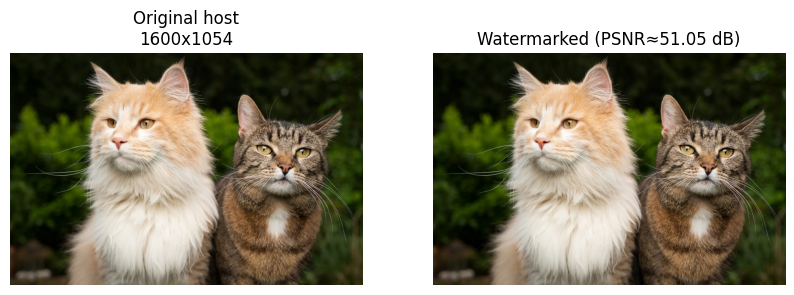

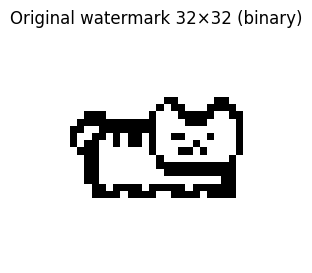

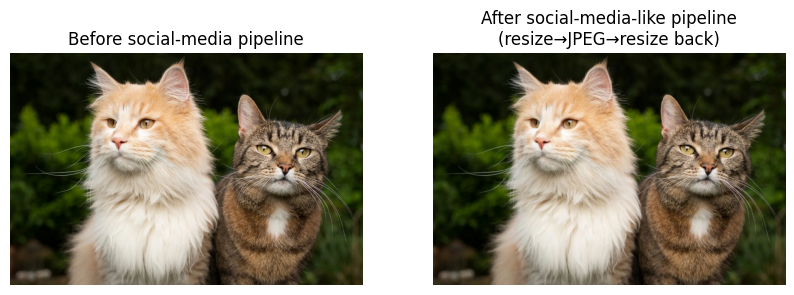

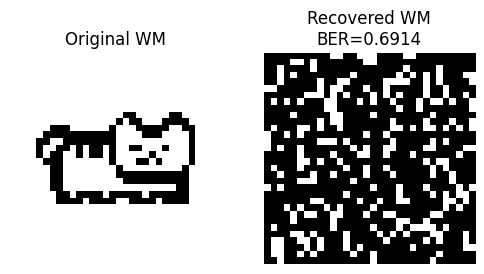

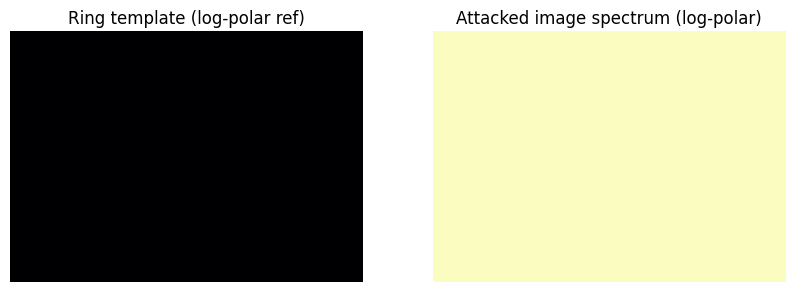

In [34]:
# Blind watermarking demo (notebook-ready, no file saves)
# - DCT + SVD-QIM (redundant) for payload
# - faint FFT ring template for rotation pre-align
# - simulates social-media pipeline (resize + JPEG in-memory)
# - shows results inline

import cv2, numpy as np, math
import matplotlib.pyplot as plt
from typing import Tuple, Dict

# -------------------------
# Small helpers (color, viz)
# -------------------------
def bgr_to_ycrcb(img_bgr: np.ndarray):
    ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    Y, Cr, Cb = cv2.split(ycrcb)
    return Y.astype(np.float32), Cr, Cb

def ycrcb_to_bgr(Y: np.ndarray, Cr: np.ndarray, Cb: np.ndarray) -> np.ndarray:
    Y = np.clip(Y, 0, 255).astype(np.uint8)
    ycrcb = cv2.merge([Y, Cr, Cb])
    return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

def to_gray(img_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

def psnr(a: np.ndarray, b: np.ndarray) -> float:
    a = a.astype(np.float32); b = b.astype(np.float32)
    mse = np.mean((a - b) ** 2)
    return 99.0 if mse == 0 else 10.0 * math.log10((255.0 ** 2) / mse)

def show_side_by_side(images, titles, cmap=None):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i, (im, title) in enumerate(zip(images, titles), 1):
        plt.subplot(1, n, i)
        if im.ndim == 2:
            plt.imshow(im, cmap=cmap or 'gray', vmin=0, vmax=255)
        else:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.title(title); plt.axis('off')
    plt.show()

# ----------------------------------
# Watermark prep (binarize to 32×32)
# ----------------------------------
def prepare_watermark(path: str, size: Tuple[int,int]=(32,32)) -> np.ndarray:
    wm_bgr = cv2.imread(path)
    if wm_bgr is None:
        raise FileNotFoundError(f"Cannot read watermark at {path}")
    wm_gray = cv2.cvtColor(wm_bgr, cv2.COLOR_BGR2GRAY)
    wm_small = cv2.resize(wm_gray, size, interpolation=cv2.INTER_AREA)
    _, wm_bin = cv2.threshold(wm_small, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return (wm_bin > 127).astype(np.uint8)  # {0,1}

# ----------------------------------------------------
# FFT ring template (imperceptible sync for rotation)
# ----------------------------------------------------
def make_ring_template(shape: Tuple[int,int],
                       radii_fracs=(0.15, 0.28),
                       sigma_px=3.0,
                       angular_modulation_strength=0.25,
                       k1=8, k2=13,
                       seed=12345) -> np.ndarray:
    """Two Gaussian rings with angular modulation in centered frequency plane."""
    h, w = shape
    cy, cx = h//2, w//2
    y = np.arange(h) - cy
    x = np.arange(w) - cx
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)
    R_max = np.sqrt((w/2)**2 + (h/2)**2) + 1e-9
    r_norm = R / R_max
    theta = np.arctan2(Y, X)

    rng = np.random.RandomState(seed)
    phi1, phi2 = rng.uniform(0, 2*np.pi, size=2)

    tmpl = np.zeros((h, w), dtype=np.float32)
    for r0, k, phi in [(radii_fracs[0], k1, phi1), (radii_fracs[1], k2, phi2)]:
        sigma_frac = sigma_px / R_max
        radial = np.exp(-0.5 * ((r_norm - r0) / (sigma_frac+1e-9))**2)
        angular = 1.0 + angular_modulation_strength * np.cos(k * theta + phi)
        tmpl += (radial * angular).astype(np.float32)

    tmpl -= tmpl.min()
    if tmpl.max() > 0: tmpl /= tmpl.max()
    return tmpl.astype(np.float32)

def apply_ring_template_to_luma(Y: np.ndarray, ring_template: np.ndarray, alpha=0.02) -> np.ndarray:
    """Multiply centered FFT magnitude by (1 + alpha*template), keep phase, iFFT back."""
    F = np.fft.fft2(Y)
    F_shift = np.fft.fftshift(F)
    mag, phase = np.abs(F_shift), np.angle(F_shift)
    mag_mod = mag * (1.0 + alpha * ring_template)
    F_new = mag_mod * np.exp(1j * phase)
    Y_new = np.fft.ifft2(np.fft.ifftshift(F_new)).real
    return Y_new.astype(np.float32)

def compute_logpolar(image: np.ndarray, center=None, out_rad=256, out_ang=360) -> np.ndarray:
    """Log-polar map via OpenCV warpPolar (stable)."""
    h, w = image.shape[:2]
    if center is None: center = (w/2, h/2)
    max_radius = min(center[0], w-center[0], center[1], h-center[1])
    if max_radius < 1: max_radius = min(h, w) / 2.0
    out_shape = (out_ang, out_rad)  # (cols, rows)
    return cv2.warpPolar(image.astype(np.float32), out_shape, center, max_radius,
                         flags=cv2.WARP_POLAR_LOG + cv2.INTER_LINEAR + cv2.WARP_FILL_OUTLIERS)

def estimate_rotation_deg_from_ring(image_y: np.ndarray, ref_logpolar: np.ndarray) -> float:
    """Estimate global rotation via log-polar magnitude phase correlation."""
    F = np.fft.fft2(image_y)
    mag = np.abs(np.fft.fftshift(F)).astype(np.float32) + 1e-6
    lp = compute_logpolar(mag)
    ref = cv2.resize(ref_logpolar, (lp.shape[1], lp.shape[0]), interpolation=cv2.INTER_AREA).astype(np.float32)
    (dx, dy), _ = cv2.phaseCorrelate(ref, lp)  # dx=theta-shift, dy=radial-shift
    width_theta = lp.shape[1]
    rot_deg = (dx * 360.0 / width_theta) % 360.0
    if rot_deg > 180: rot_deg -= 360.0
    return float(rot_deg)

def rotate_image_keep_size(img: np.ndarray, angle_deg: float) -> np.ndarray:
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle_deg, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

# -------------------------------------------------
# SVD-QIM in DCT blocks (blind, with redundancy)
# -------------------------------------------------
def dct2(block: np.ndarray) -> np.ndarray:
    return cv2.dct(block.astype(np.float32))
def idct2(block: np.ndarray) -> np.ndarray:
    return cv2.idct(block.astype(np.float32))

def qim_quantize_sigma(sigma_value: float, bit: int, delta: float) -> float:
    # Two interleaved quantizers: Δ*(k+0.25) for 0, Δ*(k+0.75) for 1
    k = math.floor(sigma_value / delta)
    return delta * (k + 0.25 + 0.5 * bit)
def qim_decode_sigma(sigma_value: float, delta: float) -> int:
    frac = (sigma_value / delta) % 1.0
    return int(frac >= 0.5)

def embed_svd_qim_in_dct(Y: np.ndarray,
                         wm_bits: np.ndarray,
                         block_size: int = 8,
                         patch_slice: Tuple[slice, slice]=(slice(2,6), slice(2,6)),
                         delta: float = 6.0,
                         repeat_per_bit: int = 6,
                         prng_seed: int = 2025) -> Tuple[np.ndarray, Dict]:
    """Embed 32×32 binary watermark redundantly across 8×8 DCT blocks (mid-band SVD-QIM)."""
    H, W = Y.shape
    wm_h, wm_w = wm_bits.shape
    total_bits = wm_h * wm_w

    Hc = (H // block_size) * block_size
    Wc = (W // block_size) * block_size
    Yc = Y[:Hc, :Wc].copy()

    blocks = [(i, j) for i in range(0, Hc, block_size) for j in range(0, Wc, block_size)]
    rng = np.random.RandomState(prng_seed); rng.shuffle(blocks)
    needed = total_bits * repeat_per_bit
    if needed > len(blocks):
        raise ValueError(f"Need {needed} blocks, but only {len(blocks)} available.")
    assigned = blocks[:needed]

    bits = wm_bits.flatten()
    mapping = []
    idx = 0
    for b_idx in range(total_bits):
        bit_val = int(bits[b_idx])
        this_bit_blocks = []
        for _ in range(repeat_per_bit):
            bi, bj = assigned[idx]; idx += 1
            this_bit_blocks.append((bi, bj))

            block = Yc[bi:bi+block_size, bj:bj+block_size].astype(np.float32)
            B = dct2(block)

            si, sj = patch_slice
            patch = B[si, sj].copy()
            U, S, Vt = np.linalg.svd(patch, full_matrices=False)
            S = S.astype(np.float32)
            S[0] = qim_quantize_sigma(S[0], bit_val, delta)
            B[si, sj] = (U @ np.diag(S) @ Vt).astype(np.float32)

            Yc[bi:bi+block_size, bj:bj+block_size] = idct2(B)
        mapping.append(this_bit_blocks)

    Y_out = Y.copy()
    Y_out[:Hc, :Wc] = Yc

    return Y_out, {
        "block_size": block_size,
        "patch_slice": (patch_slice[0].start, patch_slice[0].stop, patch_slice[1].start, patch_slice[1].stop),
        "delta": float(delta),
        "repeat_per_bit": int(repeat_per_bit),
        "prng_seed": int(prng_seed),
        "embed_size": (H, W),
        "crop_size": (Hc, Wc),
        "mapping": mapping  # debug only
    }

def extract_svd_qim_in_dct(Y: np.ndarray, wm_shape: Tuple[int,int], meta: Dict) -> np.ndarray:
    """Blind extraction: same PRNG order, decode each block, majority vote per bit."""
    H, W = Y.shape
    wm_h, wm_w = wm_shape
    total_bits = wm_h * wm_w

    block_size = meta["block_size"]
    ps0, ps1, ps2, ps3 = meta["patch_slice"]
    patch_slice = (slice(ps0, ps1), slice(ps2, ps3))
    delta = meta["delta"]
    repeat_per_bit = meta["repeat_per_bit"]
    prng_seed = meta["prng_seed"]

    Hc = (H // block_size) * block_size
    Wc = (W // block_size) * block_size
    Yc = Y[:Hc, :Wc]

    blocks = [(i, j) for i in range(0, Hc, block_size) for j in range(0, Wc, block_size)]
    rng = np.random.RandomState(prng_seed); rng.shuffle(blocks)
    needed = total_bits * repeat_per_bit
    if needed > len(blocks):
        raise ValueError("Not enough blocks during extraction.")
    assigned = blocks[:needed]

    votes = np.zeros((total_bits, repeat_per_bit), dtype=np.uint8)
    idx = 0
    for b_idx in range(total_bits):
        for r in range(repeat_per_bit):
            bi, bj = assigned[idx]; idx += 1
            B = cv2.dct(Yc[bi:bi+block_size, bj:bj+block_size].astype(np.float32))
            patch = B[patch_slice[0], patch_slice[1]]
            U, S, Vt = np.linalg.svd(patch, full_matrices=False)
            votes[b_idx, r] = int(((S[0] / delta) % 1.0) >= 0.5)

    bits_hat = (votes.mean(axis=1) >= 0.5).astype(np.uint8)
    return bits_hat.reshape((wm_h, wm_w))

# -------------------------------------------------
# Full embed/extract wrappers
# -------------------------------------------------
def embed_watermark(host_bgr: np.ndarray,
                    wm_bits: np.ndarray,
                    qim_delta: float = 6.0,
                    repeat_per_bit: int = 6,
                    ring_alpha: float = 0.02,
                    seed: int = 2025) -> Tuple[np.ndarray, Dict]:
    """Embed (ring template + SVD-QIM) and return watermarked image + meta."""
    Y, Cr, Cb = bgr_to_ycrcb(host_bgr)
    ring_tmpl = make_ring_template(Y.shape, seed=seed)
    Y_ring = apply_ring_template_to_luma(Y, ring_tmpl, alpha=ring_alpha)
    Y_emb, meta = embed_svd_qim_in_dct(Y_ring, wm_bits,
                                       block_size=8,
                                       patch_slice=(slice(2,6), slice(2,6)),
                                       delta=qim_delta,
                                       repeat_per_bit=repeat_per_bit,
                                       prng_seed=seed)
    ring_lp_ref = compute_logpolar(ring_tmpl)  # reference for rotation alignment
    meta.update({"ring_logpolar_ref": ring_lp_ref, "seed": seed})
    return ycrcb_to_bgr(Y_emb, Cr, Cb), meta

def extract_watermark(wm_bgr_in: np.ndarray,
                      wm_shape: Tuple[int,int],
                      meta: Dict,
                      try_rotation_align: bool = True) -> np.ndarray:
    """Blind extract: optional rotation alignment from ring; then SVD-QIM decode."""
    Y_in, _, _ = bgr_to_ycrcb(wm_bgr_in)
    Y_proc = Y_in.copy()
    if try_rotation_align and "ring_logpolar_ref" in meta:
        try:
            rot_deg = estimate_rotation_deg_from_ring(Y_proc, meta["ring_logpolar_ref"])
            Y_proc = rotate_image_keep_size(Y_proc, -rot_deg)  # undo rotation
        except Exception as e:
            print("[Warn] Rotation estimation failed; continuing:", e)
    return extract_svd_qim_in_dct(Y_proc, wm_shape, meta)

# -------------------------------------
# Social-media-like attack (simulation)
# -------------------------------------
def simulate_social_media_pipeline(img_bgr: np.ndarray,
                                   target_max_width: int = 1080,
                                   jpeg_quality: int = 80) -> np.ndarray:
    """Downscale to max width, JPEG round-trip in memory, then upscale to original size."""
    h, w = img_bgr.shape[:2]
    if w > target_max_width:
        ratio = target_max_width / float(w)
        resized = cv2.resize(img_bgr, (target_max_width, int(round(h * ratio))), interpolation=cv2.INTER_AREA)
    else:
        resized = img_bgr
    ok, enc = cv2.imencode('.jpg', resized, [int(cv2.IMWRITE_JPEG_QUALITY), int(jpeg_quality)])
    if not ok: raise RuntimeError("JPEG encode failed")
    decoded = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    return cv2.resize(decoded, (w, h), interpolation=cv2.INTER_LINEAR)

# ==================
# Run the full demo
# ==================
host_path = './images/cat.webp'
wm_path   = 'images/cat-sm.jpg'

host_bgr = cv2.imread(host_path)
if host_bgr is None: raise FileNotFoundError(f"Cannot read host at {host_path}")
wm_bits  = prepare_watermark(wm_path, (32, 32))

# --- EMBED ---
watermarked_bgr, meta = embed_watermark(host_bgr, wm_bits,
                                        qim_delta=6.0,
                                        repeat_per_bit=6,
                                        ring_alpha=0.02,
                                        seed=2025)

# Visualize host vs watermarked
psnr_val = psnr(to_gray(host_bgr), to_gray(watermarked_bgr))
show_side_by_side(
    [host_bgr, watermarked_bgr],
    [f"Original host\n{host_bgr.shape[1]}x{host_bgr.shape[0]}",
     f"Watermarked (PSNR≈{psnr_val:.2f} dB)"]
)

# Show original watermark
plt.figure(figsize=(3,3))
plt.imshow(wm_bits*255, cmap='gray', vmin=0, vmax=255)
plt.title("Original watermark 32×32 (binary)"); plt.axis('off'); plt.show()

# --- "SOCIAL MEDIA" ROUND-TRIP (SIMULATED) ---
attacked_bgr = simulate_social_media_pipeline(watermarked_bgr,
                                              target_max_width=1080,
                                              jpeg_quality=80)
show_side_by_side(
    [watermarked_bgr, attacked_bgr],
    ["Before social-media pipeline",
     "After social-media-like pipeline\n(resize→JPEG→resize back)"]
)

# --- EXTRACT (BLIND) ---
wm_rec_bits = extract_watermark(attacked_bgr, wm_bits.shape, meta, try_rotation_align=True)
ber_val = (wm_rec_bits.flatten() != wm_bits.flatten()).mean()

plt.figure(figsize=(6,3))
plt.subplot(1,2,1); plt.imshow(wm_bits*255, cmap='gray', vmin=0, vmax=255); plt.title("Original WM"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(wm_rec_bits*255, cmap='gray', vmin=0, vmax=255); plt.title(f"Recovered WM\nBER={ber_val:.4f}"); plt.axis('off')
plt.show()

# (Optional) peek at log-polar views of the ring reference vs attacked image spectrum
try:
    Y_att, _, _ = bgr_to_ycrcb(attacked_bgr)
    mag = np.abs(np.fft.fftshift(np.fft.fft2(Y_att))).astype(np.float32)
    lp_live = compute_logpolar(mag)
    ref_lp  = meta["ring_logpolar_ref"]
    show_side_by_side([ref_lp, lp_live],
                      ["Ring template (log-polar ref)", "Attacked image spectrum (log-polar)"],
                      cmap='magma')
except Exception as e:
    print("Log-polar visualization skipped:", e)


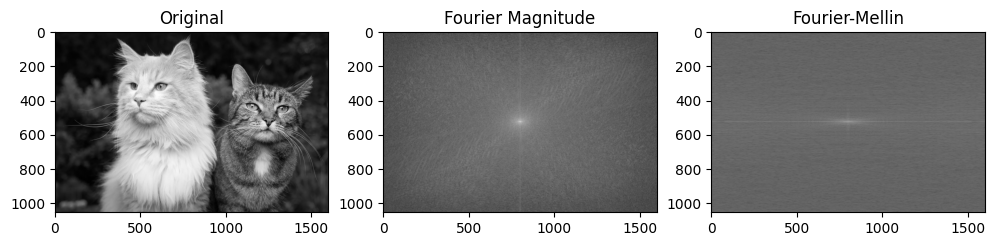

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = cv2.imread("images/cat.webp", cv2.IMREAD_GRAYSCALE)

# Step 1: Fourier Transform
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)
magnitude_spectrum = np.abs(fshift)

# Step 2: Log-polar transform
center = (magnitude_spectrum.shape[1]//2, magnitude_spectrum.shape[0]//2)
max_radius = min(center)
log_polar = cv2.logPolar(magnitude_spectrum, center, 
                         M=max_radius/np.log(max_radius), 
                         flags=cv2.INTER_LINEAR + cv2.WARP_FILL_OUTLIERS)

# Step 3: Fourier transform again (to convert shifts to peaks)
f_lp = np.fft.fft2(log_polar)
f_lp_shift = np.fft.fftshift(f_lp)
mellin = np.abs(f_lp_shift)

# Visualize
plt.figure(figsize=(12,4))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title("Original")
plt.subplot(132), plt.imshow(np.log1p(magnitude_spectrum), cmap='gray'), plt.title("Fourier Magnitude")
plt.subplot(133), plt.imshow(np.log1p(mellin), cmap='gray'), plt.title("Fourier-Mellin")
plt.show()


Embedded FM sync template.
Estimated rotation: -47.47 deg
Estimated scale:    0.1520


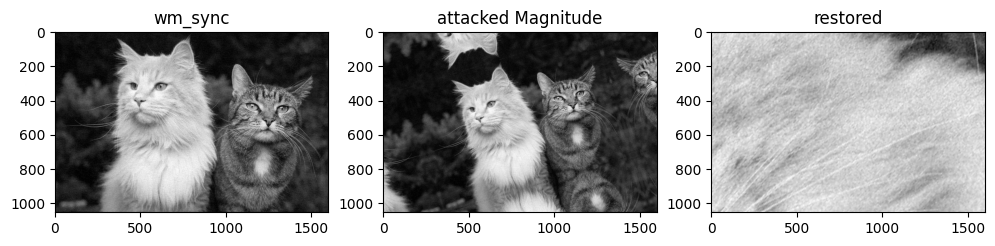

In [36]:
import cv2
import numpy as np

# ---------------------------
# Utilities
# ---------------------------
def to_gray_u8(img_bgr):
    if img_bgr.ndim == 3:
        gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    else:
        gray = img_bgr.copy()
    return gray

def fft_mag_phase(img_f32):
    f = np.fft.fft2(img_f32)
    f_shift = np.fft.fftshift(f)
    mag = np.abs(f_shift)
    phase = np.angle(f_shift)
    return mag, phase

def ifft_from_mag_phase(mag, phase):
    F_shift = mag * np.exp(1j * phase)
    F = np.fft.ifftshift(F_shift)
    img_rec = np.fft.ifft2(F)
    img_rec = np.real(img_rec)
    return img_rec

def standardize(x, eps=1e-8):
    x = x.astype(np.float32)
    return (x - np.mean(x)) / (np.std(x) + eps)

def circular_xcorr2(a, b):
    """
    Fast circular cross-correlation via FFT.
    Both inputs same shape (H, W). Returns corr map of same shape.
    Peak index = shift that best aligns b to a.
    """
    Fa = np.fft.fft2(a)
    Fb = np.fft.fft2(b)
    corr = np.fft.ifft2(Fa * np.conj(Fb))
    corr = np.real(corr)
    return corr

def peak_to_shift(peak_idx, shape):
    """Convert flat argmax index to (dy, dx) with wrap-around → signed shifts."""
    H, W = shape
    py, px = np.unravel_index(int(peak_idx), (H, W))
    # move to signed shift range [-H/2, H/2), [-W/2, W/2)
    dy = py if py < H//2 else py - H
    dx = px if px < W//2 else px - W
    return dy, dx

# ---------------------------
# Log-polar helpers
# ---------------------------
def log_polar(img, center, M):
    # Output size = same as input
    return cv2.logPolar(img, center, M, flags=cv2.INTER_LINEAR + cv2.WARP_FILL_OUTLIERS)

def inv_log_polar(img_lp, center, M):
    return cv2.logPolar(img_lp, center, M, flags=cv2.INTER_LINEAR + cv2.WARP_FILL_OUTLIERS + cv2.WARP_INVERSE_MAP)

def default_center_and_M(shape):
    H, W = shape[:2]
    cy, cx = H // 2, W // 2
    Rmax = min(cx, cy)
    # Choose M so that radial axis spans ln(Rmax)
    # This keeps units consistent: scale = exp(Δy / M)
    M = W / np.log(max(Rmax, 2))  # use width; any consistent choice is fine
    return (cx, cy), M

# ---------------------------
# Template construction
# ---------------------------
def make_lp_template_like(lp_shape, rmin_frac=0.15, rmax_frac=0.85, seed=7):
    """
    Make a zero-mean, unit-std random template in log-polar space,
    band-limited to mid-radial band to avoid DC & very high frequencies.
    """
    rng = np.random.default_rng(seed)
    H, W = lp_shape
    tpl = rng.standard_normal((H, W)).astype(np.float32)

    # Radial mask (along y). Keep mid band only.
    y = np.arange(H)[:, None]
    rmin = int(np.floor(H * rmin_frac))
    rmax = int(np.ceil (H * rmax_frac))
    mask = np.zeros((H, 1), np.float32)
    mask[rmin:rmax, 0] = 1.0

    tpl *= mask
    tpl = standardize(tpl)
    return tpl

# ---------------------------
# EMBED: add FM sync template
# ---------------------------
def embed_fmt_sync(gray_u8, alpha=0.12, rmin_frac=0.15, rmax_frac=0.85, seed=7):
    """
    Embed a Fourier–Mellin sync template into the Fourier magnitude (via log-polar).
    Returns:
      watermarked_u8, template_lp, meta(dict with center, M, H, W)
    """
    img_f = gray_u8.astype(np.float32)

    mag, phase = fft_mag_phase(img_f)
    (cx, cy), M = default_center_and_M(gray_u8.shape)
    center = (cx, cy)

    # Work in log-polar magnitude
    mag_lp = log_polar(mag, center, M)

    # Build template matched to log-polar size
    tpl_lp = make_lp_template_like(mag_lp.shape, rmin_frac, rmax_frac, seed=seed)

    # Scale the template by local magnitude energy
    strength = alpha * (np.median(mag_lp) + 1e-6)  # robust scaling
    mag_lp_wm = mag_lp + strength * tpl_lp

    # Back to Cartesian frequency magnitude
    mag_wm = inv_log_polar(mag_lp_wm, center, M)

    # Reconstruct image with original phase
    img_wm = ifft_from_mag_phase(mag_wm, phase)
    # Normalize to 8-bit safely
    img_wm = np.clip(img_wm, 0, 255).astype(np.uint8)

    meta = {"center": center, "M": M, "shape": gray_u8.shape}
    return img_wm, tpl_lp, meta

# ---------------------------
# DETECT: estimate rotation & scale
# ---------------------------
def estimate_rotation_scale(gray_u8, template_lp, meta):
    """
    Estimate rotation (deg) and scale factor using the embedded FM sync template.
    Returns rotation_deg, scale_factor, (dy, dx), corr_map
    """
    img_f = gray_u8.astype(np.float32)
    mag, _ = fft_mag_phase(img_f)

    center = meta["center"]
    M = meta["M"]
    H0, W0 = template_lp.shape

    mag_lp = log_polar(mag, center, M)  # shape ≈ input size
    # Resize to template size for correlation (robust in practice)
    mag_lp = cv2.resize(mag_lp, (W0, H0), interpolation=cv2.INTER_LINEAR)

    a = standardize(mag_lp)
    b = standardize(template_lp)

    corr = circular_xcorr2(a, b)
    peak = np.argmax(corr)
    dy, dx = peak_to_shift(peak, corr.shape)

    # Map pixel shifts to rotation & scale:
    # x (width) corresponds to angle [0..2π), y (height) to log-radius
    rotation_deg = (dx / float(W0)) * 360.0
    scale_factor = np.exp(dy / float(M))  # s = e^(Δy / M)

    return rotation_deg, scale_factor, (dy, dx), corr

# ---------------------------
# Demo
# ---------------------------
if __name__ == "__main__":
    # Load any image (uint8). Example paths:
    # host = cv2.imread("./images/cat.webp")   # your own image
    # Fallback: generate a synthetic pattern if loading fails
    host = cv2.imread("./images/cat.webp")
    if host is None:
        host = np.zeros((512, 512, 3), np.uint8)
        cv2.putText(host, "FMT", (120, 270), cv2.FONT_HERSHEY_SIMPLEX, 3, (255,255,255), 10, cv2.LINE_AA)

    gray = to_gray_u8(host)

    wm_img, template_lp, meta = embed_fmt_sync(gray, alpha=0.12, rmin_frac=0.18, rmax_frac=0.88, seed=1234)
    print("Embedded FM sync template.")

    # Simulate an R/S attack
    angle = 17.0
    scale = 0.72

    h, w = gray.shape
    M_aff = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
    attacked = cv2.warpAffine(wm_img, M_aff, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

    # Estimate rotation & scale from attacked image
    est_rot, est_scale, (dy, dx), _ = estimate_rotation_scale(attacked, template_lp, meta)
    print(f"Estimated rotation: {est_rot:.2f} deg")
    print(f"Estimated scale:    {est_scale:.4f}")

    # Re-synchronize (undo)
    M_inv = cv2.getRotationMatrix2D((w/2, h/2), -est_rot, 1.0/est_scale)
    restored = cv2.warpAffine(attacked, M_inv, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

    # Save quick checks (optional)
    # cv2.imwrite("wm_sync.png", wm_img)
    # cv2.imwrite("attacked.png", attacked)
    # cv2.imwrite("restored.png", restored)
    # print("Wrote wm_sync.png, attacked.png, restored.png")
# Visualize
plt.figure(figsize=(12,4))
plt.subplot(131), plt.imshow(wm_img, cmap='gray'), plt.title("wm_sync")
plt.subplot(132), plt.imshow(attacked, cmap='gray'), plt.title("attacked Magnitude")
plt.subplot(133), plt.imshow(restored, cmap='gray'), plt.title("restored")
plt.show()

# Sync Template (FMT)

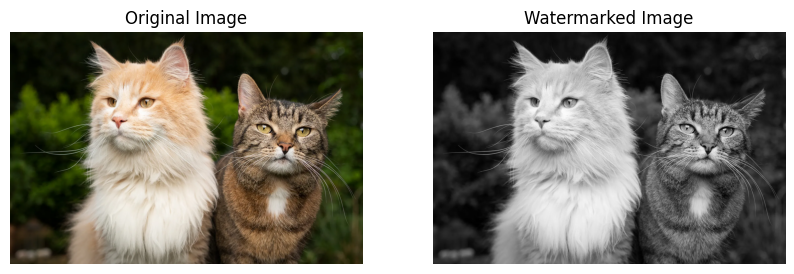

Correlation score with template: 2618503.9111328125


In [45]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ----------------------------
# 1. Generate pseudorandom template
# ----------------------------
def generate_template(size=(32, 32), seed=42):
    rng = np.random.default_rng(seed)
    # values in {-1, +1}
    template = rng.choice([-1, 1], size=size)
    return template

# ----------------------------
# 2. Embed template into frequency domain of an image
# ----------------------------
def embed_template(image, template, alpha=20):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = gray.astype(np.float32)

    # DFT (frequency domain)
    dft = np.fft.fft2(gray)
    dft_shift = np.fft.fftshift(dft)

    # Embed template into top-left corner of magnitude spectrum
    mag = np.abs(dft_shift)
    phase = np.angle(dft_shift)

    h, w = template.shape
    mag[:h, :w] += alpha * template  # embed template

    # Reconstruct image
    dft_embed = mag * np.exp(1j * phase)
    dft_embed = np.fft.ifftshift(dft_embed)
    watermarked = np.fft.ifft2(dft_embed).real
    watermarked = np.clip(watermarked, 0, 255).astype(np.uint8)

    return watermarked

# ----------------------------
# 3. Detect template by correlation
# ----------------------------
def detect_template(image, template):
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32)
    else:
        gray = image.astype(np.float32)
    dft = np.fft.fft2(gray)
    dft_shift = np.fft.fftshift(dft)

    mag = np.abs(dft_shift)

    h, w = template.shape
    region = mag[:h, :w]

    # correlation with the expected template
    score = np.sum(region * template)
    return score

# ----------------------------
# Example run
# ----------------------------
# Load host image
seed = 1234
host = cv2.imread("./images/cat.webp")  # <-- replace with your own image
template2embed = generate_template(size=(32, 32), seed=seed)

# Embed
watermarked = embed_template(host, template2embed)

template2extract = generate_template(size=(32, 32), seed=seed)  # same seed

# Detect
score = detect_template(watermarked, template2extract)

# Show results
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.title("Original Image"); plt.imshow(cv2.cvtColor(host, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,2,2); plt.title("Watermarked Image"); plt.imshow(watermarked, cmap="gray"); plt.axis("off")
plt.show()

print("Correlation score with template:", score)

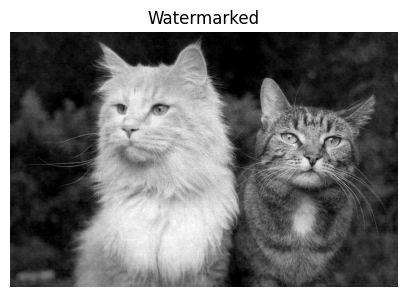

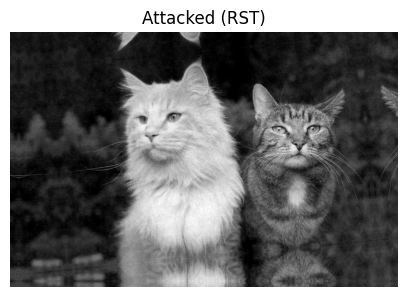

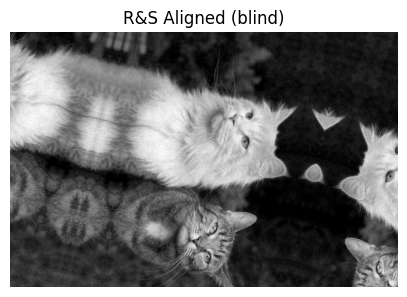

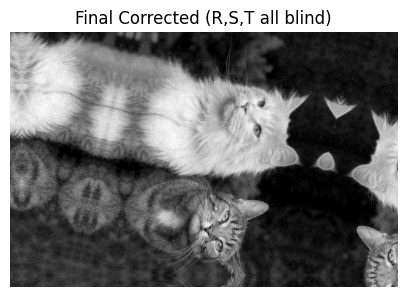

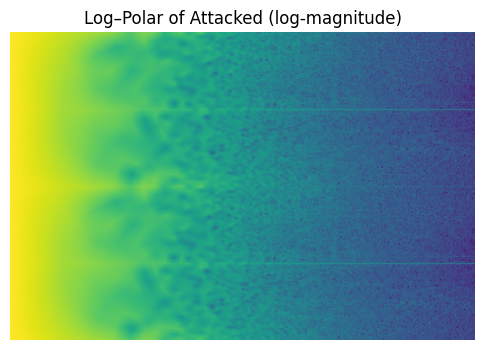

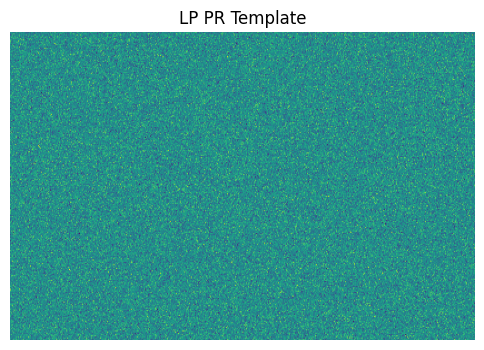

=== Ground Truth Attack ===
Rotation: 5.50 deg, Scale: 0.8000, Translation: (tx=36, ty=-24)
=== Blind Estimates ===
Rotation: 103.36 deg, Scale: 1.1582
Translation: dy=48.00, dx=-49.00
PSNR (watermarked vs attacked):  12.79 dB
PSNR (watermarked vs corrected): 8.74 dB


In [50]:
# Fully BLIND RST synchronization with dual pseudorandom templates
# - Template LP (log–polar FFT magnitude) => estimates rotation & scale (blind)
# - Template XY (spatial-domain PN)       => estimates translation (blind) after R&S correction
#
# Pipeline:
#   1) Embed LP in log–polar log-magnitude of FFT (for R&S)
#   2) Reconstruct image; then add spatial PN XY (for T)
#   3) Attack with rotation, scale, translation
#   4) Detect R&S via LP correlation (blind)
#   5) Correct R&S
#   6) Detect translation via phase correlation with spatial PN template XY (blind)
#   7) Correct translation
#
# Notes:
# - This demo uses a synthetic host so it's runnable anywhere.
# - Parameters (ALPHA_LP, BETA_XY) trade imperceptibility vs sync strength.
# - All detections are BLIND: they use only the attacked image and the known seeds/templates.
#
# You can swap the synthetic image with your own by reading with cv2.imread().

import numpy as np
import cv2
import matplotlib.pyplot as plt

# ----------------------
# Utilities
# ----------------------
def ensure_bgr(img):
    if img.ndim == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    return img

def make_demo_host(w=512, h=512):
    """Create a synthetic host image if no file is provided."""
    img = np.zeros((h, w, 3), np.uint8)
    # background gradient
    for i in range(h):
        img[i, :, :] = (i * 255 // h)
    # draw shapes/text
    cv2.circle(img, (w//3, h//3), 60, (255, 255, 255), 3)
    cv2.rectangle(img, (w//2 - 80, h//2 - 50), (w//2 + 80, h//2 + 50), (220, 220, 220), 2)
    cv2.putText(img, "PR-Template", (40, h - 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255,255,255), 2, cv2.LINE_AA)
    return img

def psnr(x, y):
    x = x.astype(np.float32)
    y = y.astype(np.float32)
    mse = np.mean((x - y) ** 2)
    if mse == 0:
        return 99.0
    return 20 * np.log10(255.0 / np.sqrt(mse))

def fft_mag_phase(gray):
    F = np.fft.fft2(gray)
    Fshift = np.fft.fftshift(F)
    mag = np.abs(Fshift)
    phase = np.angle(Fshift)
    return mag, phase

def ifft_from_mag_phase(mag, phase):
    Fshift = mag * np.exp(1j * phase)
    F = np.fft.ifftshift(Fshift)
    img = np.fft.ifft2(F).real
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def to_log_polar(img, center, maxRadius, dsize):
    # cv2.warpPolar expects size as (width, height)
    lp = cv2.warpPolar(
        img, dsize, center, maxRadius,
        cv2.WARP_POLAR_LOG + cv2.WARP_FILL_OUTLIERS + cv2.INTER_LINEAR
    )
    return lp

def from_log_polar(lp, center, maxRadius, dsize):
    cart = cv2.warpPolar(
        lp, dsize, center, maxRadius,
        cv2.WARP_POLAR_LOG + cv2.WARP_FILL_OUTLIERS + cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP
    )
    return cart

def hann2d(h, w):
    winy = np.hanning(h)
    winx = np.hanning(w)
    return np.outer(winy, winx)

def phase_corr_shift(a, b):
    """Return (dy, dx) shift that best aligns 'a' to 'b' via phase correlation."""
    # zero-mean & window to reduce edge artifacts
    a0 = (a - np.mean(a)) * hann2d(*a.shape)
    b0 = (b - np.mean(b)) * hann2d(*b.shape)

    A = np.fft.fft2(a0)
    B = np.fft.fft2(b0)
    R = A * np.conj(B)
    R /= np.maximum(1e-12, np.abs(R))
    r = np.fft.ifft2(R).real

    maxloc = np.unravel_index(np.argmax(r), r.shape)
    shifts = np.array(maxloc, dtype=np.float64)

    # wrap around
    if shifts[0] > a.shape[0] // 2:
        shifts[0] -= a.shape[0]
    if shifts[1] > a.shape[1] // 2:
        shifts[1] -= a.shape[1]

    peak = r[maxloc]
    return (shifts[0], shifts[1], float(peak))

def apply_affine(img, M, dsize):
    return cv2.warpAffine(img, M, dsize, flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

def rotation_scale_matrix(center, angle_deg, scale):
    M = cv2.getRotationMatrix2D(center, angle_deg, scale)
    return M

def translate_matrix(tx, ty):
    M = np.array([[1, 0, tx],
                  [0, 1, ty]], dtype=np.float32)
    return M

# ----------------------
# Pseudorandom templates
# ----------------------
def generate_pr_template(shape, seed=123):
    rng = np.random.default_rng(seed)
    T = rng.standard_normal(shape).astype(np.float32)
    T -= np.mean(T)
    T /= (np.std(T) + 1e-8)
    return T

def bandpass_template_xy(shape, seed=99, low_sigma=1.0, high_sigma=3.0):
    """Zero-mean PN field bandpassed (DoG) and windowed to reduce host interference."""
    T = generate_pr_template(shape, seed=seed)
    # Difference-of-Gaussians to emphasize mid-high frequencies
    ksize = int(6 * high_sigma + 1) | 1
    blur_lo = cv2.GaussianBlur(T, (ksize, ksize), low_sigma)
    blur_hi = cv2.GaussianBlur(T, (ksize, ksize), high_sigma)
    B = blur_lo - blur_hi
    # Window
    H = hann2d(*shape)
    B *= H
    # Normalize
    B -= np.mean(B)
    B /= (np.std(B) + 1e-8)
    return B.astype(np.float32)

# ----------------------
# Embedding
# ----------------------
def embed_dual_templates(image_bgr, T_lp, T_xy, alpha_lp=0.25, beta_xy=3.0, H_LP=256, W_LP=512):
    """Embed LP (log–polar) into log-FFT magnitude and XY in spatial domain."""
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)

    # --- LP in log-magnitude ---
    mag, phase = fft_mag_phase(gray)
    logmag = np.log1p(mag)

    h, w = gray.shape
    center = (w / 2.0, h / 2.0)
    maxRadius = int(min(center)) - 1

    lp = to_log_polar(logmag, center, maxRadius, (W_LP, H_LP))
    if T_lp.shape != lp.shape:
        T_lp_res = cv2.resize(T_lp, (lp.shape[1], lp.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        T_lp_res = T_lp

    lp_embed = lp + alpha_lp * T_lp_res
    logmag_embed = from_log_polar(lp_embed, center, maxRadius, (w, h))
    mag_embed = np.expm1(logmag_embed)
    im1 = ifft_from_mag_phase(mag_embed, phase).astype(np.float32)

    # --- XY in spatial (additive) ---
    if T_xy.shape != (h, w):
        T_xy_res = cv2.resize(T_xy, (w, h), interpolation=cv2.INTER_CUBIC)
    else:
        T_xy_res = T_xy
    im2 = im1 + beta_xy * T_xy_res
    im2 = np.clip(im2, 0, 255).astype(np.uint8)

    watermarked_bgr = ensure_bgr(im2)

    params = {
        "center": center,
        "maxRadius": maxRadius,
        "H_LP": H_LP,
        "W_LP": W_LP
    }
    return watermarked_bgr, params

# ----------------------
# Detection: R&S from LP, T from XY
# ----------------------
def estimate_rotation_scale(attacked_bgr, T_lp, params):
    gray = cv2.cvtColor(attacked_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    mag, _ = fft_mag_phase(gray)
    logmag = np.log1p(mag)

    center = params["center"]
    maxRadius = params["maxRadius"]
    H_LP = params["H_LP"]
    W_LP = params["W_LP"]

    lp = to_log_polar(logmag, center, maxRadius, (W_LP, H_LP))

    if T_lp.shape != lp.shape:
        T_lp_res = cv2.resize(T_lp, (lp.shape[1], lp.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        T_lp_res = T_lp

    dy, dx, peak = phase_corr_shift(lp, T_lp_res)

    rot_est_deg = (dx / W_LP) * 360.0
    s_est = np.exp((dy / H_LP) * np.log(maxRadius + 1.0))

    return rot_est_deg, s_est, dict(peak=peak, dy=dy, dx=dx, lp_attacked=lp, lp_template=T_lp_res)

def correct_rotation_scale(attacked_bgr, rot_est_deg, s_est):
    h, w = attacked_bgr.shape[:2]
    center = (w/2.0, h/2.0)
    M_rs = rotation_scale_matrix(center, -rot_est_deg, 1.0/np.maximum(1e-6, s_est))
    rs_aligned = apply_affine(attacked_bgr, M_rs, (w, h))
    return rs_aligned

def estimate_translation_blind(rs_aligned_bgr, T_xy):
    """Blind translation via phase correlation between image and known spatial PN template."""
    h, w = rs_aligned_bgr.shape[:2]
    gray = cv2.cvtColor(rs_aligned_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    if T_xy.shape != (h, w):
        T_xy_res = cv2.resize(T_xy, (w, h), interpolation=cv2.INTER_CUBIC)
    else:
        T_xy_res = T_xy

    dy, dx, peak = phase_corr_shift(gray, T_xy_res)
    return dy, dx, dict(peak=peak)

def apply_translation(img_bgr, dy, dx):
    M_t = translate_matrix(-dx, -dy)  # negative to undo the measured shift
    h, w = img_bgr.shape[:2]
    out = apply_affine(img_bgr, M_t, (w, h))
    return out

# ----------------------
# Demo pipeline
# ----------------------
# Host
host = cv2.imread("./images/cat.webp")  # <-- replace with your own image

# Templates
H_LP, W_LP = 256, 512
T_LP = generate_pr_template((H_LP, W_LP), seed=7)        # for rotation & scale (log–polar)
T_XY = bandpass_template_xy((host.shape[0], host.shape[1]), seed=33)  # for translation (spatial)

# Embed
ALPHA_LP = 0.25
BETA_XY  = 3.0
watermarked, params = embed_dual_templates(host, T_LP, T_XY, alpha_lp=ALPHA_LP, beta_xy=BETA_XY, H_LP=H_LP, W_LP=W_LP)

# Attack (RST)
ang = 5.5        # degrees
scl = 0.80        # isotropic scale
tx, ty = 36, -24  # translation in pixels

h, w = watermarked.shape[:2]
center = (w/2.0, h/2.0)
M_rs = rotation_scale_matrix(center, ang, scl)
attacked_rs = apply_affine(watermarked, M_rs, (w, h))
M_t = translate_matrix(tx, ty)
attacked = apply_affine(attacked_rs, M_t, (w, h))

# === BLIND detection & correction ===
# 1) R & S from LP
rot_est_deg, s_est, info_rs = estimate_rotation_scale(attacked, T_LP, params)
rs_aligned = correct_rotation_scale(attacked, rot_est_deg, s_est)

# 2) Translation from XY (blind)
t_dy, t_dx, info_t = estimate_translation_blind(rs_aligned, T_XY)
rst_corrected = apply_translation(rs_aligned, t_dy, t_dx)

# Metrics (vs watermarked, for reporting only)
psnr_attacked = psnr(cv2.cvtColor(watermarked, cv2.COLOR_BGR2GRAY),
                     cv2.cvtColor(attacked, cv2.COLOR_BGR2GRAY))
psnr_corrected = psnr(cv2.cvtColor(watermarked, cv2.COLOR_BGR2GRAY),
                      cv2.cvtColor(rst_corrected, cv2.COLOR_BGR2GRAY))

# ----------------------
# Visualize (single plot per figure)
# ----------------------
plt.figure(figsize=(5,5))
plt.title("Watermarked")
plt.imshow(cv2.cvtColor(watermarked, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

plt.figure(figsize=(5,5))
plt.title("Attacked (RST)")
plt.imshow(cv2.cvtColor(attacked, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

plt.figure(figsize=(5,5))
plt.title("R&S Aligned (blind)")
plt.imshow(cv2.cvtColor(rs_aligned, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

plt.figure(figsize=(5,5))
plt.title("Final Corrected (R,S,T all blind)")
plt.imshow(cv2.cvtColor(rst_corrected, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Show attacked LP plane and LP template
plt.figure(figsize=(6,4))
plt.title("Log–Polar of Attacked (log-magnitude)")
plt.imshow(info_rs["lp_attacked"], aspect='auto')
plt.axis("off")
plt.show()

plt.figure(figsize=(6,4))
plt.title("LP PR Template")
plt.imshow(info_rs["lp_template"], aspect='auto')
plt.axis("off")
plt.show()

print("=== Ground Truth Attack ===")
print(f"Rotation: {ang:.2f} deg, Scale: {scl:.4f}, Translation: (tx={tx}, ty={ty})")
print("=== Blind Estimates ===")
print(f"Rotation: {rot_est_deg:.2f} deg, Scale: {s_est:.4f}")
print(f"Translation: dy={t_dy:.2f}, dx={t_dx:.2f}")
print(f"PSNR (watermarked vs attacked):  {psnr_attacked:.2f} dB")
print(f"PSNR (watermarked vs corrected): {psnr_corrected:.2f} dB")


Correcting: angle=49.22°, scale=5.563, new_size=(287, 189)
Bit Error Rate (BER): 1.0


TypeError: Image data of dtype object cannot be converted to float

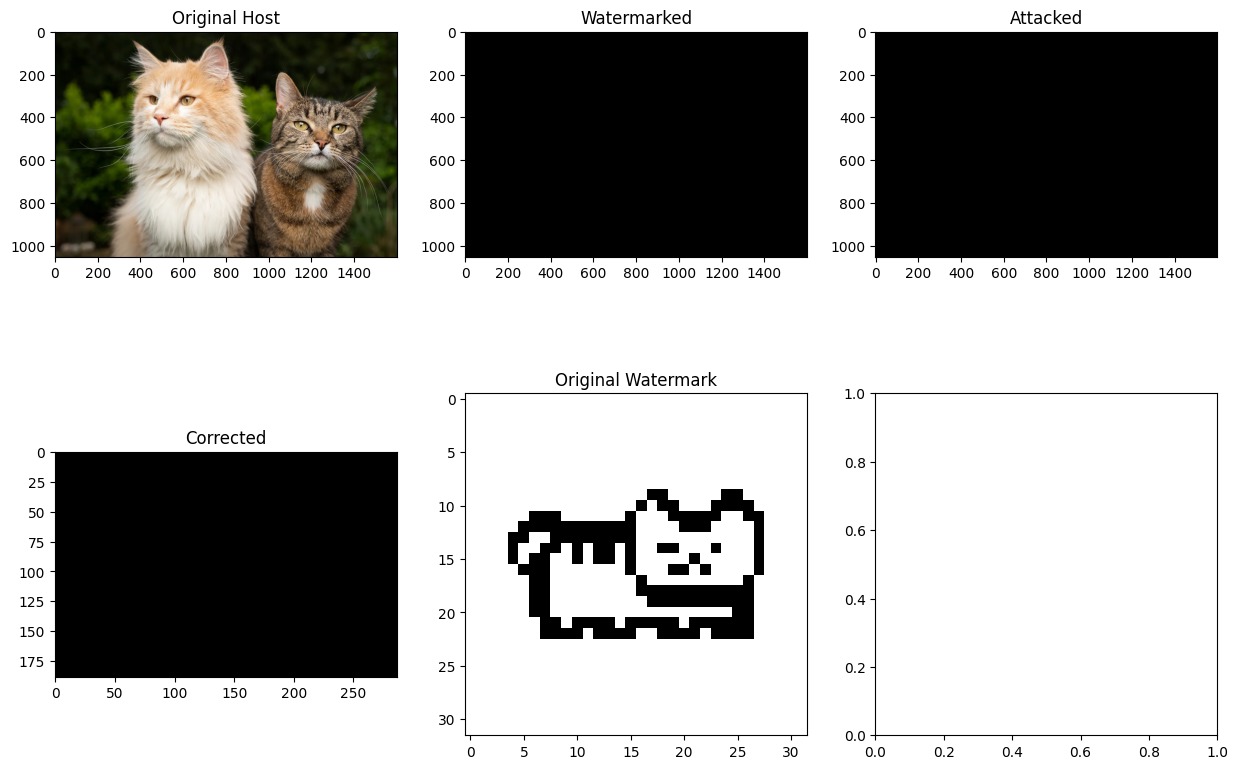

In [ ]:
import cv2
import numpy as np
from skimage.transform import warp_polar
from skimage.registration import phase_cross_correlation
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

# Fixed parameters
N_THETA = 256
N_R = 128
BETA = 0.1  # Strength for template embedding
DELTA = 20.0  # Strength for DCT adjustment
WM_SIZE = 32
R_MIN = 1.0
np.random.seed(42)
TEMPLATE = np.random.choice([-1.0, 1.0], size=(N_THETA, N_R))

def rgb_to_yuv(img):
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    u = -0.147 * r - 0.289 * g + 0.436 * b
    v = 0.615 * r - 0.515 * g - 0.100 * b
    return y, u, v

def yuv_to_rgb(y, u, v):
    r = y + 1.140 * v
    g = y - 0.395 * u - 0.581 * v
    b = y + 2.032 * u
    return np.stack((np.clip(r, 0, 255), np.clip(g, 0, 255), np.clip(b, 0, 255)), axis=2).astype(np.uint8)

def embed_sync(host_img):
    is_color = len(host_img.shape) == 3
    if is_color:
        y, u, v = rgb_to_yuv(host_img.astype(float) / 255.0)
        host_gray = y * 255.0
    else:
        host_gray = host_img.astype(float)

    h, w = host_gray.shape
    size = int(np.ceil(np.sqrt(h**2 + w**2)))
    pad_h1 = (size - h) // 2
    pad_h2 = size - h - pad_h1
    pad_w1 = (size - w) // 2
    pad_w2 = size - w - pad_w1
    padded = np.pad(host_gray, ((pad_h1, pad_h2), (pad_w1, pad_w2)), mode='constant')

    F = np.fft.fft2(padded)
    mag = np.abs(F)
    phase = np.angle(F)

    # Log-polar transform using warp_polar
    max_r = size // 2
    lpm = warp_polar(mag, scaling='log', output_shape=(N_THETA, N_R), radius=max_r)

    # Embed template
    lpm_new = lpm + BETA * np.mean(lpm) * TEMPLATE

    # Inverse log-polar
    freq_range = np.arange(size) - size / 2
    fx, fy = np.meshgrid(freq_range, freq_range)
    r = np.sqrt(fx**2 + fy**2)
    theta_vals = np.arctan2(fy, fx) % (2 * np.pi)
    rho = np.log(np.maximum(r, R_MIN))
    mask = (r >= R_MIN) & (r <= max_r)

    log_r = np.linspace(np.log(R_MIN), np.log(max_r), N_R)
    theta_grid = np.linspace(0, 2 * np.pi, N_THETA, endpoint=False)
    Theta_grid, Log_r_grid = np.meshgrid(theta_grid, log_r)  # Wait, warp_polar outputs rows=theta, cols=log_r
    points = np.column_stack((Theta_grid.flatten(), Log_r_grid.flatten()))
    values = lpm_new.flatten()
    query_points = np.column_stack((theta_vals[mask], rho[mask]))
    interp_values = griddata(points, values, query_points, method='linear', fill_value=0)
    new_mag = np.zeros_like(mag)
    new_mag[mask] = interp_values
    new_mag = (new_mag + new_mag[::-1, ::-1]) / 2

    F_new = new_mag * np.exp(1j * phase)
    synced_padded = np.real(np.fft.ifft2(F_new))
    synced = synced_padded[pad_h1:pad_h1 + h, pad_w1:pad_w1 + w]

    if is_color:
        y_synced = synced / 255.0
        rgb_synced = yuv_to_rgb(y_synced, u, v)
        return rgb_synced
    else:
        return synced.astype(np.uint8)

def embed_payload(synced_img, wm_bin):
    is_color = len(synced_img.shape) == 3
    if is_color:
        y, u, v = rgb_to_yuv(synced_img.astype(float) / 255.0)
        synced_gray = y * 255.0
    else:
        synced_gray = synced_img.astype(float)

    h, w = synced_gray.shape
    if h < WM_SIZE * 8 or w < WM_SIZE * 8:
        raise ValueError("Image too small for watermark")

    watermarked = synced_gray.copy()

    for i in range(WM_SIZE):
        for j in range(WM_SIZE):
            bit = wm_bin[i, j]
            block = watermarked[i*8:(i+1)*8, j*8:(j+1)*8]
            dct = cv2.dct(block.astype(np.float32))
            c1 = dct[1,4]
            c2 = dct[4,1]
            diff = c1 - c2
            if (bit == 1 and diff <= 0) or (bit == 0 and diff > 0):
                adj = DELTA + abs(diff)
                if bit == 1:
                    dct[1,4] += adj / 2
                    dct[4,1] -= adj / 2
                else:
                    dct[1,4] -= adj / 2
                    dct[4,1] += adj / 2
            block_new = cv2.idct(dct)
            watermarked[i*8:(i+1)*8, j*8:(j+1)*8] = block_new

    if is_color:
        y_watermarked = watermarked / 255.0
        rgb_watermarked = yuv_to_rgb(y_watermarked, u, v)
        return rgb_watermarked
    else:
        return watermarked.astype(np.uint8)

def correct_rst_and_extract(watermarked_attacked):
    is_color = len(watermarked_attacked.shape) == 3
    if is_color:
        attacked_gray = cv2.cvtColor(watermarked_attacked, cv2.COLOR_BGR2GRAY)
    else:
        attacked_gray = watermarked_attacked

    h, w = attacked_gray.shape
    size = int(np.ceil(np.sqrt(h**2 + w**2)))
    pad_h1 = (size - h) // 2
    pad_h2 = size - h - pad_h1
    pad_w1 = (size - w) // 2
    pad_w2 = size - w - pad_w1
    padded = np.pad(attacked_gray, ((pad_h1, pad_h2), (pad_w1, pad_w2)), mode='constant')

    F = np.fft.fft2(padded)
    mag = np.abs(F)

    max_r = size // 2
    lpm = warp_polar(mag, scaling='log', output_shape=(N_THETA, N_R), radius=max_r)

    # Phase correlation
    shift = phase_cross_correlation(lpm, TEMPLATE, normalization=None)

    theta_shift = shift[0]
    log_r_shift = shift[1]

    angle = -theta_shift * 360 / N_THETA
    scale = np.exp(log_r_shift * np.log(max_r / R_MIN) / N_R)

    # Correct the image
    corrected = watermarked_attacked if is_color else watermarked_attacked[:,:,np.newaxis]
    if not is_color:
        corrected = cv2.cvtColor(corrected, cv2.COLOR_GRAY2BGR)  # Temporary for consistency
    
    print(h, w, scale)

    new_h, new_w = int(h / scale), int(w / scale)
    scaled = cv2.resize(corrected, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    center = (new_w // 2, new_h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(scaled, M, (new_w, new_h), flags=cv2.INTER_LINEAR)
    corrected_img = rotated if is_color else cv2.cvtColor(rotated, cv2.COLOR_BGR2GRAY)

    # Now search for translation alignment via block grid
    corrected_gray = cv2.cvtColor(corrected_img, cv2.COLOR_BGR2GRAY) if is_color else corrected_img
    max_score = -np.inf
    extracted_wm = None
    for dy in range(8):
        for dx in range(8):
            shift_m = np.float32([[1, 0, dx], [0, 1, dy]])
            shifted = cv2.warpAffine(corrected_gray, shift_m, (new_w, new_h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
            bits = np.zeros((WM_SIZE, WM_SIZE))
            diffs = []
            valid = True
            for i in range(WM_SIZE):
                for j in range(WM_SIZE):
                    y_start, x_start = i*8, j*8
                    block = shifted[y_start:y_start+8, x_start:x_start+8]
                    if block.shape != (8, 8):
                        valid = False
                        break
                    dct = cv2.dct(block.astype(np.float32))
                    c1 = dct[1,4]
                    c2 = dct[4,1]
                    diffs.append(abs(c1 - c2))
                    bits[i, j] = 1 if c1 > c2 else 0
                if not valid:
                    break
            if not valid:
                continue
            score = np.mean(diffs)
            if score > max_score:
                max_score = score
                extracted_wm = bits
    return extracted_wm, corrected_gray

if __name__ == "__main__":
    # Load host image
    host_path = 'images/cat.webp'
    host_img = cv2.imread(host_path)
    if host_img is None:
        raise FileNotFoundError("Host image not found")

    # Load watermark image
    wm_path = 'images/cat-sm.jpg'
    wm_img = cv2.imread(wm_path, cv2.IMREAD_GRAYSCALE)
    if wm_img is None:
        raise FileNotFoundError("Watermark image not found")
    _, wm_bin = cv2.threshold(wm_img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    wm_bin = cv2.resize(wm_bin, (WM_SIZE, WM_SIZE), interpolation=cv2.INTER_NEAREST) / 255

    cv2.imshow("watermark", wm_bin * 255)
    cv2.waitKey(0)

    # Embed sync template
    synced_img = embed_sync(host_img)

    # Embed payload
    watermarked_img = embed_payload(synced_img, wm_bin)

    # Save watermarked
    cv2.imwrite('watermarked.png', watermarked_img)

    # Simulate attack: rotation 5 deg, scale 0.85, translation (5,5)
    is_color = len(watermarked_img.shape) == 3
    center = (watermarked_img.shape[1] // 2, watermarked_img.shape[0] // 2)
    M = cv2.getRotationMatrix2D(center, 5, 0.85)
    M[0, 2] += 5
    M[1, 2] += 5
    attacked = cv2.warpAffine(watermarked_img, M, (watermarked_img.shape[1], watermarked_img.shape[0]), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)

    # Extract
    extracted_wm, corrected_img = correct_rst_and_extract(attacked)

    # Compute BER
    ber = np.mean(wm_bin != extracted_wm)
    print(f"Bit Error Rate (BER): {ber}")

    # Display results
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    axs[0, 0].imshow(cv2.cvtColor(host_img, cv2.COLOR_BGR2RGB) if is_color else host_img, cmap='gray' if not is_color else None)
    axs[0, 0].set_title('Original Host')
    axs[0, 1].imshow(cv2.cvtColor(watermarked_img, cv2.COLOR_BGR2RGB) if is_color else watermarked_img, cmap='gray' if not is_color else None)
    axs[0, 1].set_title('Watermarked')
    axs[0, 2].imshow(cv2.cvtColor(attacked, cv2.COLOR_BGR2RGB) if is_color else attacked, cmap='gray' if not is_color else None)
    axs[0, 2].set_title('Attacked')
    axs[1, 0].imshow(corrected_img, cmap='gray')
    axs[1, 0].set_title('Corrected')
    axs[1, 1].imshow(wm_bin, cmap='gray')
    axs[1, 1].set_title('Original Watermark')
    axs[1, 2].imshow(extracted_wm, cmap='gray')
    axs[1, 2].set_title('Extracted Watermark')
    for ax in axs.flat:
        ax.axis('off')
    plt.tight_layout()
    plt.show()